# 天池工业蒸汽量预测项目

## 1. 项目背景

工业生产过程中通常会采集大量传感器变量，这些变量反映了不同阶段的运行状态。工业蒸汽量预测任务的目标，是根据已有的多维工业特征，建立回归模型预测目标变量 `target`。

本项目使用天池工业蒸汽量预测数据集，其中训练集包含多个匿名特征 `V0`~`V37` 以及目标变量 `target`，测试集只包含对应特征。项目将依次完成数据读取、数据探索、预处理、特征处理、模型比较、模型评估、结果可视化以及可解释性分析。

本次实验不会只以最终 MSE 为目标，而是重点建立一套完整、可复现、可解释的机器学习工作流程。

### 1.1 导入依赖与环境说明

本项目使用 Python 3.11 作为运行环境，并在独立的 Conda 环境 `steam-prediction` 中完成实验，以减少不同项目之间的依赖冲突，并提高实验的可复现性。

本节首先导入数据分析和可视化所需的基础库：

- `NumPy`：用于数值计算和数组运算；
- `pandas`：用于读取、整理和分析表格数据；
- `Matplotlib`：用于基础数据可视化；
- `Seaborn`：用于绘制统计图形，使变量分布和变量关系更直观。

后续建模阶段还会根据需要继续导入 `scikit-learn`、`XGBoost`、`LightGBM` 和 `SHAP` 等机器学习与解释性分析工具。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 数据文件路径与数据读取

本项目将原始数据统一存放在 `data/raw/` 目录中，避免直接修改原始文件。

训练集 `zhengqi_train.txt` 包含输入特征 `V0`~`V37` 以及目标变量 `target`；测试集 `zhengqi_test.txt` 仅包含输入特征，不包含 `target`。

本节使用 `pandas.read_csv()` 读取数据，并首先检查数据维度与前几行内容，确认文件是否读取正确。

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

train_path = DATA_DIR / "zhengqi_train.txt"
test_path = DATA_DIR / "zhengqi_test.txt"

train_data = pd.read_csv(train_path, sep="\t")
test_data = pd.read_csv(test_path, sep="\t")

In [4]:
print("训练集形状：", train_data.shape)
print("测试集形状：", test_data.shape)

display(train_data.head())
display(test_data.head())

训练集形状： (2888, 39)
测试集形状： (1925, 38)


,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V29,V30,V31,V32,V33,V34,V35,V36,V37,target
0,0.566,0.016,-0.143,0.407,0.452,-0.901,-1.812,-2.360,-0.436,-2.114,...,0.136,0.109,-0.615,0.327,-4.627,-4.789,-5.101,-2.608,-3.508,0.175
1,0.968,0.437,0.066,0.566,0.194,-0.893,-1.566,-2.360,0.332,-2.114,...,-0.128,0.124,0.032,0.600,-0.843,0.160,0.364,-0.335,-0.730,0.676
2,1.013,0.568,0.235,0.370,0.112,-0.797,-1.367,-2.360,0.396,-2.114,...,-0.009,0.361,0.277,-0.116,-0.843,0.160,0.364,0.765,-0.589,0.633
3,0.733,0.368,0.283,0.165,0.599,-0.679,-1.200,-2.086,0.403,-2.114,...,0.015,0.417,0.279,0.603,-0.843,-0.065,0.364,0.333,-0.112,0.206
4,0.684,0.638,0.260,0.209,0.337,-0.454,-1.073,-2.086,0.314,-2.114,...,0.183,1.078,0.328,0.418,-0.843,-0.215,0.364,-0.280,-0.028,0.384


,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37
0,0.368,0.380,-0.225,-0.049,0.379,0.092,0.550,0.551,0.244,0.904,...,-0.449,0.047,0.057,-0.042,0.847,0.534,-0.009,-0.190,-0.567,0.388
1,0.148,0.489,-0.247,-0.049,0.122,-0.201,0.487,0.493,-0.127,0.904,...,-0.443,0.047,0.560,0.176,0.551,0.046,-0.220,0.008,-0.294,0.104
2,-0.166,-0.062,-0.311,0.046,-0.055,0.063,0.485,0.493,-0.227,0.904,...,-0.458,-0.398,0.101,0.199,0.634,0.017,-0.234,0.008,0.373,0.569
3,0.102,0.294,-0.259,0.051,-0.183,0.148,0.474,0.504,0.010,0.904,...,-0.456,-0.398,1.007,0.137,1.042,-0.040,-0.290,0.008,-0.666,0.391
4,0.300,0.428,0.208,0.051,-0.033,0.116,0.408,0.497,0.155,0.904,...,-0.458,-0.776,0.291,0.370,0.181,-0.040,-0.290,0.008,-0.140,-0.497


### 1.3 保留原始数据副本

为了避免后续数据清洗、特征处理或变量变换直接修改原始数据，本项目首先保存训练集和测试集的原始副本。

后续实验尽量在副本上进行处理，这样即使处理中出现错误，也可以随时回到最初的数据状态。

In [5]:
train_raw = train_data.copy()
test_raw = test_data.copy()

print("原始训练集副本：", train_raw.shape)
print("原始测试集副本：", test_raw.shape)

原始训练集副本： (2888, 39)
原始测试集副本： (1925, 38)


## 2. 数据质量检查

### 2.1 缺失值与重复值检查

在正式分析和建模之前，需要先检查数据中是否存在缺失值或重复样本。

缺失值可能导致部分模型无法直接训练；重复样本则可能使模型对某些数据模式产生偏倚，因此需要在建模前先确认数据质量。

In [6]:
print("训练集缺失值总数：", train_data.isnull().sum().sum())
print("测试集缺失值总数：", test_data.isnull().sum().sum())

print("训练集重复行数量：", train_data.duplicated().sum())
print("测试集重复行数量：", test_data.duplicated().sum())

训练集缺失值总数： 0
测试集缺失值总数： 0
训练集重复行数量： 0
测试集重复行数量： 0


### 2.2 数据类型与基本统计特征

除了缺失值和重复值，还需要检查各特征的数据类型以及数值范围。

本数据集中的特征应主要为数值型变量。通过描述性统计可以初步了解每个变量的均值、标准差、最小值、最大值和四分位数，为后续异常值分析和标准化处理提供依据。

In [7]:
# 数据类型统计
dtype_counts = train_data.dtypes.value_counts()
print(dtype_counts)

# 描述性统计
describe_df = train_data.describe().T
display(describe_df)

# 保存结果
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

dtype_counts.to_csv(
    RESULTS_DIR / "data_type_counts.csv",
    header=["count"]
)

describe_df.to_csv(
    RESULTS_DIR / "descriptive_statistics.csv"
)

print("统计结果已保存到 results/ 目录")

float64    39
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
V0,2888.0,0.123048,0.928031,-4.335,-0.29700,0.3590,0.72600,2.121
V1,2888.0,0.056068,0.941515,-5.122,-0.22625,0.2725,0.59900,1.918
V2,2888.0,0.289720,0.911236,-3.420,-0.31300,0.3860,0.91825,2.828
V3,2888.0,-0.067790,0.970298,-3.956,-0.65225,-0.0445,0.62400,2.457
V4,2888.0,0.012921,0.888377,-4.742,-0.38500,0.1100,0.55025,2.689
V5,2888.0,-0.558565,0.517957,-2.182,-0.85300,-0.4660,-0.15400,0.489
V6,2888.0,0.182892,0.918054,-4.576,-0.31000,0.3880,0.83125,1.895
V7,2888.0,0.116155,0.955116,-5.048,-0.29500,0.3440,0.78225,1.918
V8,2888.0,0.177856,0.895444,-4.692,-0.15900,0.3620,0.72600,2.245
V9,2888.0,-0.169452,0.953813,-12.891,-0.39000,0.0420,0.04200,1.335


统计结果已保存到 results/ 目录


### 2.3 无穷值检查

除了缺失值外，还需要检查数据中是否存在正无穷或负无穷值。

无穷值虽然不是缺失值，但会导致部分统计计算、标准化和机器学习模型出现异常，因此需要在建模前单独确认。

In [8]:
train_inf_count = np.isinf(train_data.select_dtypes(include=np.number)).sum().sum()
test_inf_count = np.isinf(test_data.select_dtypes(include=np.number)).sum().sum()

print("训练集无穷值数量：", train_inf_count)
print("测试集无穷值数量：", test_inf_count)

训练集无穷值数量： 0
测试集无穷值数量： 0


### 2.4 目标变量分布分析

目标变量 `target` 是本项目需要预测的工业蒸汽量。

在建模前，需要先观察 `target` 的分布形态，判断是否存在明显偏态、极端值或多峰现象。目标变量的分布会影响模型训练难度，也有助于后续分析预测误差。

In [9]:
target_stats = train_data["target"].describe()
display(target_stats)

target_stats.to_csv(
    RESULTS_DIR / "target_descriptive_statistics.csv",
    header=["value"]
)

count    2888.000000
mean        0.126353
std         0.983966
min        -3.044000
25%        -0.350250
50%         0.313000
75%         0.793250
max         2.538000
Name: target, dtype: float64

### 2.5 目标变量分布可视化

仅依靠均值和四分位数无法直观看出目标变量的分布形态，因此进一步绘制直方图和核密度曲线。

直方图用于观察不同取值区间内的样本数量，核密度曲线用于观察整体分布趋势。

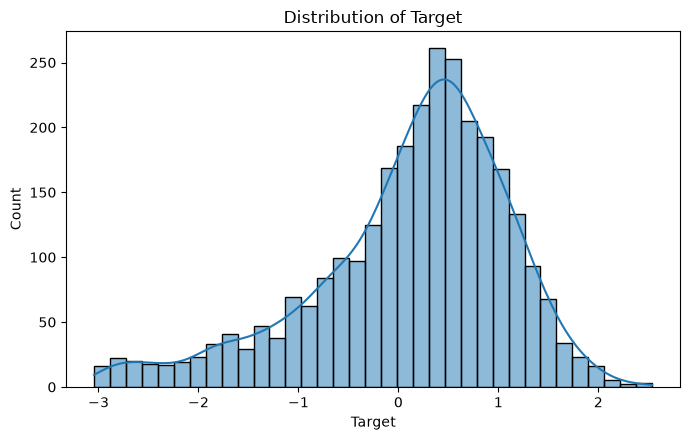

In [10]:
plt.figure(figsize=(7, 4.5))

sns.histplot(
    train_data["target"],
    bins=35,
    kde=True
)

plt.title("Distribution of Target")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()

FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

plt.savefig(
    FIGURES_DIR / "target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 2.6 特征分布与异常值初步检查

工业数据中的不同传感器变量可能具有不同的取值范围，也可能存在少量极端值。

本节使用箱线图对全部特征进行整体检查，重点观察：

- 不同特征的数值尺度是否差异明显；
- 是否存在大量离群点；
- 是否有部分变量分布异常。

需要注意的是，箱线图中的离群点不一定代表错误数据，因此本项目不会仅凭箱线图直接删除样本，而是结合后续模型表现进一步判断。

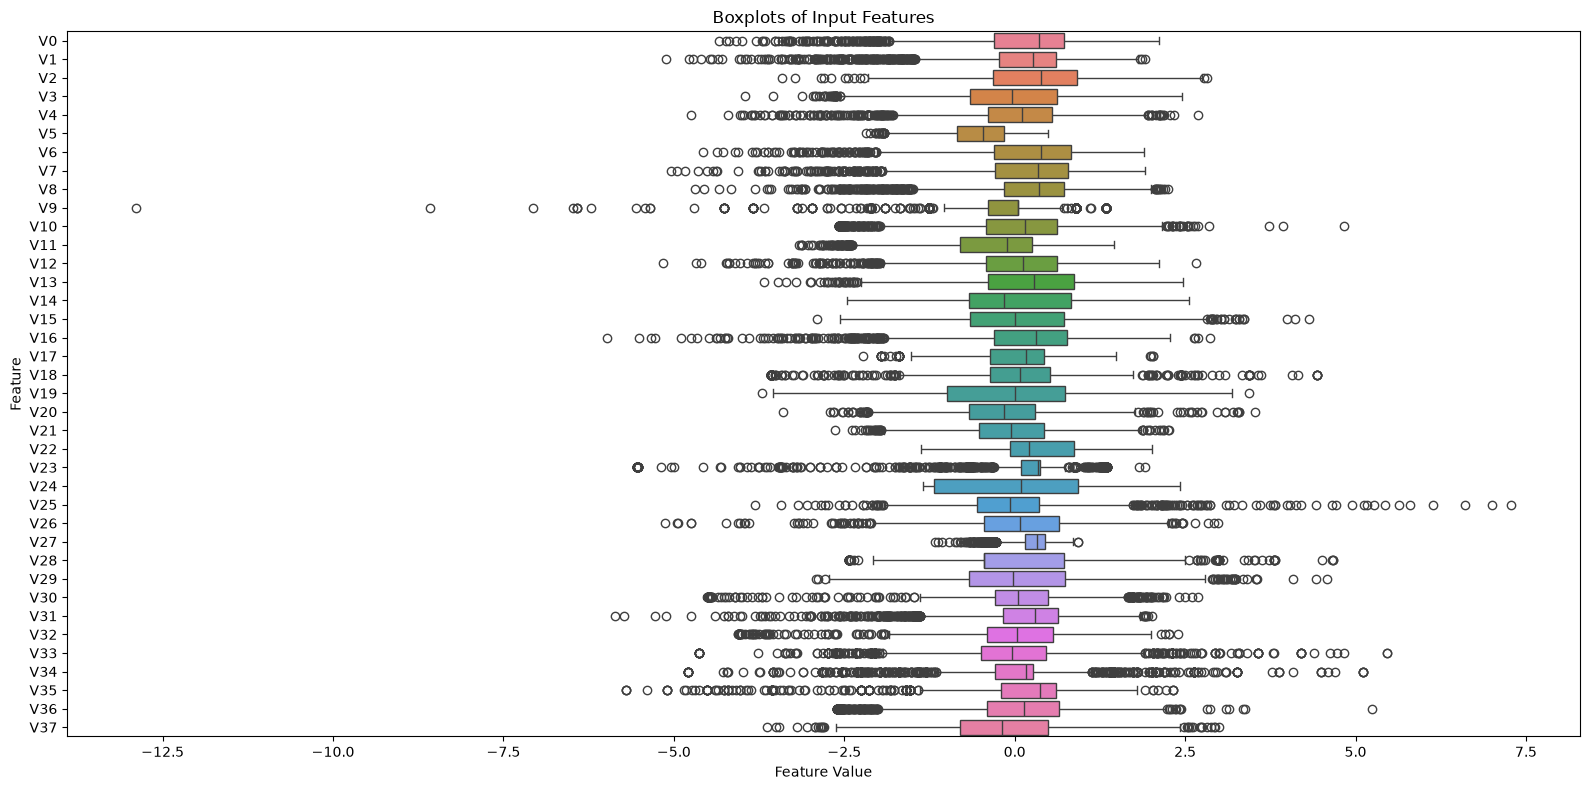

In [11]:
feature_cols = [col for col in train_data.columns if col != "target"]

plt.figure(figsize=(16, 8))

sns.boxplot(
    data=train_data[feature_cols],
    orient="h"
)

plt.title("Boxplots of Input Features")
plt.xlabel("Feature Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 2.7 基于 IQR 的异常值数量统计

箱线图能够直观看到离群点，但难以准确比较不同特征的异常程度。

因此进一步使用四分位距（IQR）规则统计每个特征的离群点数量和比例。该统计仅用于描述数据分布，不作为直接删除样本的依据。

In [12]:
outlier_stats = []

for col in feature_cols:
    q1 = train_data[col].quantile(0.25)
    q3 = train_data[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (train_data[col] < lower_bound) |
        (train_data[col] > upper_bound)
    )

    outlier_count = outlier_mask.sum()
    outlier_ratio = outlier_count / len(train_data)

    outlier_stats.append({
        "feature": col,
        "outlier_count": outlier_count,
        "outlier_ratio": outlier_ratio
    })

outlier_df = pd.DataFrame(outlier_stats)
outlier_df = outlier_df.sort_values("outlier_ratio", ascending=False)

display(outlier_df.head(10))

,feature,outlier_count,outlier_ratio
9,V9,835,0.289127
23,V23,700,0.242382
34,V34,488,0.168975
1,V1,220,0.076177
33,V33,217,0.075139
31,V31,191,0.066136
8,V8,184,0.063712
18,V18,179,0.061981
10,V10,177,0.061288
36,V36,167,0.057825


In [13]:
outlier_df.to_csv(
    RESULTS_DIR / "iqr_outlier_statistics.csv",
    index=False
)

print("IQR异常值统计已保存")

IQR异常值统计已保存


### 2.8 特征与目标变量的相关性分析

为了初步判断各输入特征与目标变量 `target` 之间的线性关系，本节计算 Pearson 相关系数。

相关系数绝对值越大，说明该特征与 `target` 的线性关系越明显；但相关系数较低并不代表该特征一定没有预测价值，因为后续树模型仍可能学习到非线性关系。

In [14]:
corr_with_target = (
    train_data.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

display(corr_with_target.head(10))

V0     0.873212
V1     0.871846
V8     0.831904
V27    0.812585
V31    0.750297
V2     0.638878
V4     0.603984
V12    0.594189
V37   -0.565795
V16    0.536748
Name: target, dtype: float64

In [15]:
corr_df = corr_with_target.reset_index()
corr_df.columns = ["feature", "correlation"]

corr_df.to_csv(
    RESULTS_DIR / "feature_target_correlation.csv",
    index=False
)

print("特征相关性统计已保存")

特征相关性统计已保存


### 2.9 高相关特征可视化

为了更直观地比较不同特征与目标变量 `target` 的线性相关程度，本节选取绝对相关系数最高的 10 个特征进行可视化。

该图主要回答：哪些特征与目标变量的线性关系最明显，以及相关方向是正还是负。

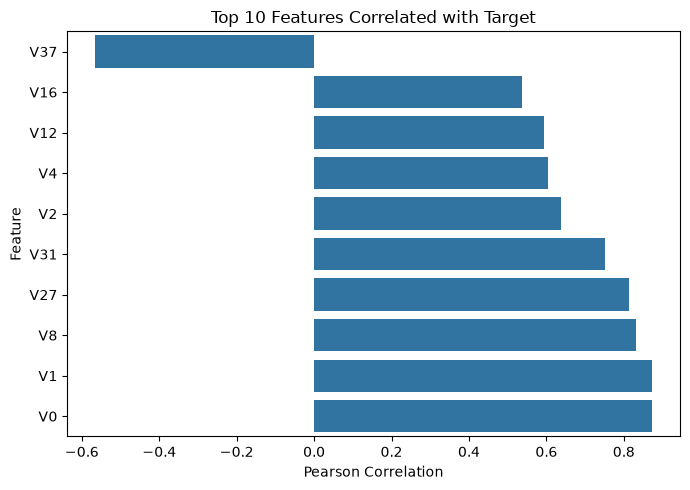

In [16]:
top10_corr = corr_df.head(10).sort_values("correlation")

plt.figure(figsize=(7, 5))

sns.barplot(
    data=top10_corr,
    x="correlation",
    y="feature"
)

plt.title("Top 10 Features Correlated with Target")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 2.10 高相关特征之间的相关性分析

部分特征虽然与目标变量具有较高相关性，但这些特征之间也可能存在较强相关关系，从而产生信息冗余。

因此，本节进一步分析高相关特征之间的 Pearson 相关系数，以观察特征之间是否存在明显共线性，为后续特征选择、PCA 和模型选择提供依据。

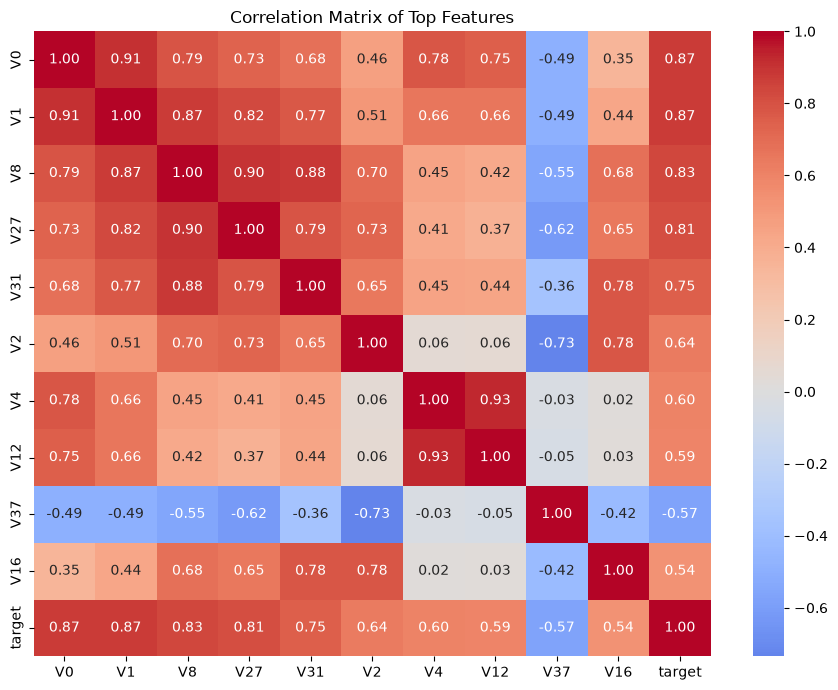

In [17]:
top_features = corr_df.head(10)["feature"].tolist()

corr_matrix = train_data[top_features + ["target"]].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Top Features")
plt.tight_layout()
plt.show()

In [18]:
corr_matrix.to_csv(
    RESULTS_DIR / "top_features_correlation_matrix.csv"
)

print("相关矩阵已保存")

相关矩阵已保存


### 2.11 高相关特征与目标变量的散点关系

Pearson 相关系数只能反映线性相关程度，不能直接展示变量之间的具体关系形态。

因此，本节选取与 `target` 相关性最高的前 4 个特征绘制散点图，观察其关系是否近似线性，以及是否存在明显的非线性结构或局部异常点。

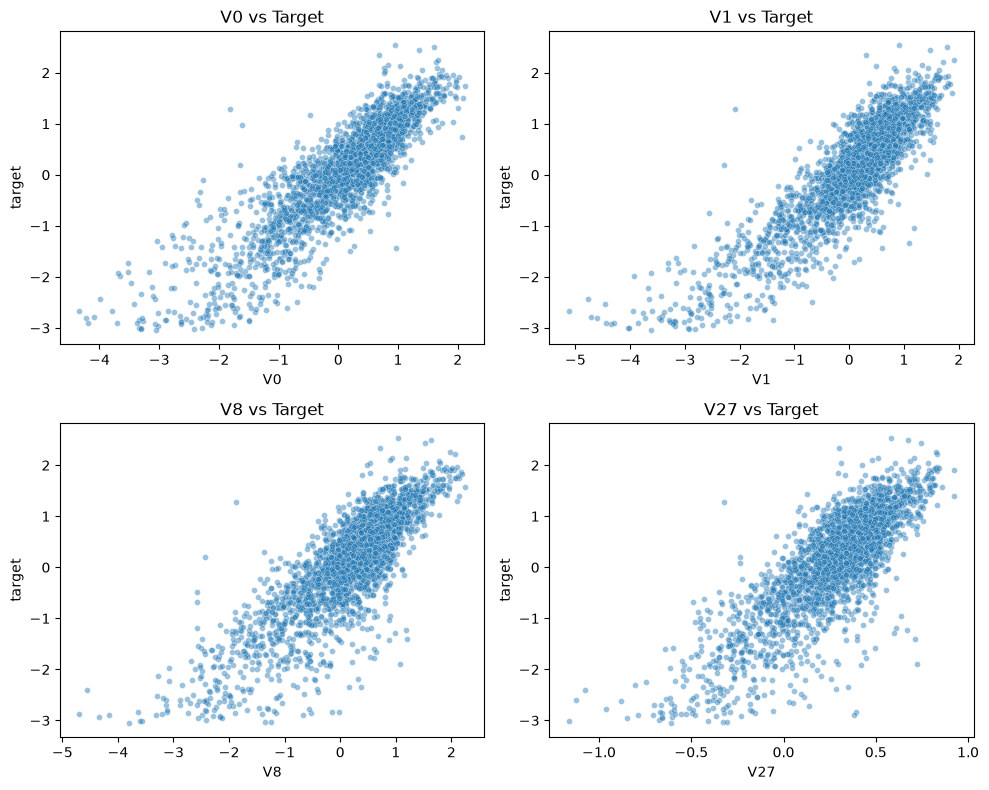

In [19]:
top4_features = corr_df.head(4)["feature"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, feature in zip(axes.flatten(), top4_features):
    sns.scatterplot(
        data=train_data,
        x=feature,
        y="target",
        alpha=0.45,
        s=18,
        ax=ax
    )
    
    ax.set_title(f"{feature} vs Target")

plt.tight_layout()
plt.show()

### 2.12 数据探索阶段小结

通过前述数据质量检查和探索性分析，可以得到以下结论：

1. 训练集包含 2888 个样本、38 个输入特征和 1 个目标变量，测试集包含 1925 个样本和 38 个输入特征。
2. 数据中不存在缺失值、重复样本和无穷值，基础数据质量较好。
3. 目标变量整体呈单峰分布，并存在一定左偏特征。
4. 多个输入特征存在较多基于 IQR 规则识别出的离群点，其中 V9、V23 和 V34 的离群比例较高，因此不能简单依据箱线图删除异常样本。
5. V0、V1、V8 和 V27 与目标变量具有较强的正相关关系，V37 与目标变量具有较明显的负相关关系。
6. 部分高相关特征之间也存在较强共线性，例如 V0 与 V1、V4 与 V12 等，说明特征中存在一定信息冗余。
7. 高相关特征与目标变量的散点关系总体接近线性，但仍存在局部离散和异常点。

基于以上分析，后续建模阶段将同时比较保留全部特征、特征筛选和降维等不同方案，并通过多种回归模型验证其实际预测效果。

## 3. 数据预处理与特征处理

机器学习模型不能直接把整个训练表作为输入，因为训练集中既包含输入特征，也包含需要预测的目标变量 `target`。

因此，本章首先将训练数据划分为输入特征矩阵 `X` 和目标变量 `y`，并保证测试集只保留与训练集一致的输入特征。

后续的标准化、特征筛选和降维操作都将基于这一划分进行。

### 3.1 划分输入特征与目标变量

In [20]:
X = train_data.drop(columns=["target"])
y = train_data["target"]

X_test = test_data.copy()

print("训练特征 X：", X.shape)
print("训练目标 y：", y.shape)
print("测试特征 X_test：", X_test.shape)

训练特征 X： (2888, 38)
训练目标 y： (2888,)
测试特征 X_test： (1925, 38)


### 3.2 特征尺度检查

不同特征的数值范围和波动程度可能不同。对于 Ridge 等基于线性系数和正则化的模型，如果不同特征尺度差异较大，可能导致某些特征在优化过程中占据更大的影响。

因此，在使用 Ridge、PCA 等方法前，需要考虑对特征进行标准化。

需要注意的是，随机森林、GBDT、XGBoost 和 LightGBM 等树模型通常不依赖特征标准化，因此后续不会对所有模型机械地使用同一种预处理方式。

In [21]:
scale_stats = pd.DataFrame({
    "mean": X.mean(),
    "std": X.std(),
    "min": X.min(),
    "max": X.max()
})

display(scale_stats.head(10))

,mean,std,min,max
V0,0.123048,0.928031,-4.335,2.121
V1,0.056068,0.941515,-5.122,1.918
V2,0.289720,0.911236,-3.420,2.828
V3,-0.067790,0.970298,-3.956,2.457
V4,0.012921,0.888377,-4.742,2.689
V5,-0.558565,0.517957,-2.182,0.489
V6,0.182892,0.918054,-4.576,1.895
V7,0.116155,0.955116,-5.048,1.918
V8,0.177856,0.895444,-4.692,2.245
V9,-0.169452,0.953813,-12.891,1.335


### 3.3 标准化方法设置

虽然原始特征整体已经接近零均值和单位方差，但不同特征仍存在一定尺度差异和极端取值。

因此，对于 Ridge 和 PCA 等对特征尺度较敏感的方法，后续使用 `StandardScaler` 进行标准化。

为了避免数据泄漏，标准化参数只能在训练折上学习，不能先使用全部数据计算均值和标准差，因此后续会将 `StandardScaler` 放入 `Pipeline` 中。

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

print("StandardScaler 已创建，暂未拟合数据。")

StandardScaler 已创建，暂未拟合数据。


### 3.4 Ridge 基线模型与 Pipeline

Ridge 是在线性回归基础上加入 L2 正则化的回归模型，可以在一定程度上缓解多重共线性带来的系数不稳定问题。

由于 Ridge 对特征尺度比较敏感，因此本项目将 `StandardScaler` 和 `Ridge` 放入同一个 `Pipeline` 中。

这样在交叉验证的每一折中，标准化参数只会根据当前训练折计算，再作用于验证折，从而避免数据泄漏。

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

print(ridge_pipeline)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])


### 3.5 交叉验证策略

为了更可靠地评估模型性能，本项目不只进行一次训练集/验证集划分，而是使用交叉验证。

考虑到原项目中采用了按样本顺序划分的 `TimeSeriesSplit`，本次继续保留这一设计，使验证过程不打乱原始样本顺序，并与原实验保持可比性。

In [24]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


### 3.6 Ridge 基线交叉验证

为了建立后续模型比较的基准，本节首先使用 Ridge 回归进行 5 折时间顺序交叉验证。

这里首先采用均方误差（MSE）作为核心评价指标。MSE 会对较大的预测误差给予更高惩罚，因此适合衡量回归模型整体预测误差水平。

后续还会进一步加入 RMSE、MAE 和 R²，从多个角度评估模型性能。

In [25]:
from sklearn.model_selection import cross_val_score

ridge_mse_scores = -cross_val_score(
    ridge_pipeline,
    X,
    y,
    cv=tscv,
    scoring="neg_mean_squared_error"
)

print("每折 MSE：", ridge_mse_scores)
print("平均 MSE：", ridge_mse_scores.mean())
print("MSE 标准差：", ridge_mse_scores.std())

每折 MSE： [0.10709132 0.1188086  0.14388392 0.10617653 0.17689779]
平均 MSE： 0.13057163122601453
MSE 标准差： 0.026863152186898054


In [26]:
ridge_cv_df = pd.DataFrame({
    "fold": np.arange(1, len(ridge_mse_scores) + 1),
    "mse": ridge_mse_scores
})

ridge_cv_df.to_csv(
    RESULTS_DIR / "ridge_baseline_cv_mse.csv",
    index=False
)

display(ridge_cv_df)

,fold,mse
0,1,0.107091
1,2,0.118809
2,3,0.143884
3,4,0.106177
4,5,0.176898


### 3.7 Ridge 基线的多指标评估

单独使用 MSE 不能完整反映模型性能，因此进一步计算 RMSE、MAE 和 R²。

- MSE：对大误差惩罚更强；
- RMSE：与目标变量单位一致，更直观；
- MAE：表示平均绝对误差，对异常值更稳健；
- R²：衡量模型对目标变量变化的解释程度，越接近 1 越好。

In [27]:
from sklearn.model_selection import cross_validate

ridge_cv_result = cross_validate(
    ridge_pipeline,
    X,
    y,
    cv=tscv,
    scoring={
        "mse": "neg_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
)

ridge_metrics_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "mse": -ridge_cv_result["test_mse"],
    "mae": -ridge_cv_result["test_mae"],
    "r2": ridge_cv_result["test_r2"]
})

ridge_metrics_df["rmse"] = np.sqrt(ridge_metrics_df["mse"])

display(ridge_metrics_df)

print("平均 MSE：", ridge_metrics_df["mse"].mean())
print("平均 RMSE：", ridge_metrics_df["rmse"].mean())
print("平均 MAE：", ridge_metrics_df["mae"].mean())
print("平均 R²：", ridge_metrics_df["r2"].mean())

,fold,mse,mae,r2,rmse
0,1,0.107091,0.247788,0.870844,0.327248
1,2,0.118809,0.253509,0.870535,0.344686
2,3,0.143884,0.288694,0.865512,0.379320
3,4,0.106177,0.243466,0.835965,0.325847
4,5,0.176898,0.288107,0.818673,0.420592


平均 MSE： 0.13057163122601453
平均 RMSE： 0.3595388525744186
平均 MAE： 0.26431288062912284
平均 R²： 0.8523057246546134


In [28]:
ridge_metrics_df.to_csv(
    RESULTS_DIR / "ridge_baseline_cv_metrics.csv",
    index=False
)

ridge_summary = pd.DataFrame({
    "model": ["Ridge"],
    "mse_mean": [ridge_metrics_df["mse"].mean()],
    "rmse_mean": [ridge_metrics_df["rmse"].mean()],
    "mae_mean": [ridge_metrics_df["mae"].mean()],
    "r2_mean": [ridge_metrics_df["r2"].mean()]
})

ridge_summary.to_csv(
    RESULTS_DIR / "ridge_baseline_summary.csv",
    index=False
)

display(ridge_summary)

,model,mse_mean,rmse_mean,mae_mean,r2_mean
0,Ridge,0.130572,0.359539,0.264313,0.852306


### 3.8 KBest 特征筛选

前面的相关性分析表明，不同特征与目标变量的关系强弱存在明显差异。

因此，本节使用 `SelectKBest` 对特征进行筛选。这里采用回归任务常用的 `f_regression` 评分方法，根据每个特征与目标变量之间的线性统计关系进行排序，并保留得分最高的若干特征。

需要注意的是，特征筛选同样不能提前在全部数据上完成，否则会产生数据泄漏，因此后续会把它放入 `Pipeline` 中。

In [29]:
from sklearn.feature_selection import SelectKBest, f_regression

kbest_selector = SelectKBest(
    score_func=f_regression,
    k=20
)

print(kbest_selector)

SelectKBest(k=20, score_func=<function f_regression at 0x0000023E818BD260>)


### 3.9 KBest 特征筛选与 Ridge 联合建模

为了公平比较“使用全部特征”和“经过特征筛选后再建模”的效果，本节将 `SelectKBest`、`StandardScaler` 和 `Ridge` 放入同一个 `Pipeline` 中。

这样在每一折交叉验证中，特征筛选和标准化都只基于当前训练折完成，再作用于验证折，从而避免数据泄漏。

In [30]:
kbest_ridge_pipeline = Pipeline([
    ("kbest", SelectKBest(score_func=f_regression, k=20)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

print(kbest_ridge_pipeline)

Pipeline(steps=[('kbest',
                 SelectKBest(k=20,
                             score_func=<function f_regression at 0x0000023E818BD260>)),
                ('scaler', StandardScaler()), ('ridge', Ridge())])


### 3.10 KBest 特征筛选效果评估

为了判断特征筛选是否真正提升模型性能，本节使用与基线模型相同的 `TimeSeriesSplit` 和评价指标，对 `KBest + Ridge` 进行交叉验证。

这样可以公平比较：

- 使用全部 38 个特征的 Ridge；
- 仅使用筛选后 20 个特征的 Ridge。

如果筛选后误差更低，说明去除部分冗余或弱相关特征可能有帮助；如果误差反而升高，则说明被删除的特征中仍包含有效预测信息。

In [31]:
kbest_cv_result = cross_validate(
    kbest_ridge_pipeline,
    X,
    y,
    cv=tscv,
    scoring={
        "mse": "neg_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
)

kbest_metrics_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "mse": -kbest_cv_result["test_mse"],
    "mae": -kbest_cv_result["test_mae"],
    "r2": kbest_cv_result["test_r2"]
})

kbest_metrics_df["rmse"] = np.sqrt(kbest_metrics_df["mse"])

display(kbest_metrics_df)

print("平均 MSE：", kbest_metrics_df["mse"].mean())
print("平均 RMSE：", kbest_metrics_df["rmse"].mean())
print("平均 MAE：", kbest_metrics_df["mae"].mean())
print("平均 R²：", kbest_metrics_df["r2"].mean())

,fold,mse,mae,r2,rmse
0,1,0.106821,0.252310,0.871170,0.326834
1,2,0.133521,0.261742,0.854502,0.365406
2,3,0.156179,0.296280,0.854020,0.395194
3,4,0.119022,0.266212,0.816120,0.344995
4,5,0.179093,0.291665,0.816423,0.423194


平均 MSE： 0.1389270913048876
平均 RMSE： 0.37112473594178746
平均 MAE： 0.27364171646476765
平均 R²： 0.8424471111297229


In [32]:
kbest_metrics_df.to_csv(
    RESULTS_DIR / "kbest20_ridge_cv_metrics.csv",
    index=False
)

kbest_summary = pd.DataFrame({
    "model": ["KBest20 + Ridge"],
    "mse_mean": [kbest_metrics_df["mse"].mean()],
    "rmse_mean": [kbest_metrics_df["rmse"].mean()],
    "mae_mean": [kbest_metrics_df["mae"].mean()],
    "r2_mean": [kbest_metrics_df["r2"].mean()]
})

kbest_summary.to_csv(
    RESULTS_DIR / "kbest20_ridge_summary.csv",
    index=False
)

### 3.11 PCA 降维与 Ridge 建模

前面的相关性分析表明，部分特征之间存在较强共线性，例如 V0 与 V1、V4 与 V12 等。

PCA（主成分分析）可以把原始特征转换为一组彼此正交的新特征，在尽量保留数据主要信息的同时减少特征冗余。

由于 PCA 对特征尺度敏感，因此需要先标准化，再进行 PCA，最后接入 Ridge 回归模型。

In [33]:
from sklearn.decomposition import PCA

pca_ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("ridge", Ridge(alpha=1.0))
])

print(pca_ridge_pipeline)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)),
                ('ridge', Ridge())])


### 3.12 PCA 降维效果评估

为了判断 PCA 是否能够在减少特征冗余的同时保持甚至提升预测性能，本节使用与前面相同的交叉验证策略，对 `PCA + Ridge` 进行评估。

如果 PCA 后模型误差降低，说明降维有助于去除冗余信息；如果误差升高，则说明原始特征中被压缩掉的部分仍包含有效预测信息。

In [34]:
pca_cv_result = cross_validate(
    pca_ridge_pipeline,
    X,
    y,
    cv=tscv,
    scoring={
        "mse": "neg_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
)

pca_metrics_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "mse": -pca_cv_result["test_mse"],
    "mae": -pca_cv_result["test_mae"],
    "r2": pca_cv_result["test_r2"]
})

pca_metrics_df["rmse"] = np.sqrt(pca_metrics_df["mse"])

display(pca_metrics_df)

print("平均 MSE：", pca_metrics_df["mse"].mean())
print("平均 RMSE：", pca_metrics_df["rmse"].mean())
print("平均 MAE：", pca_metrics_df["mae"].mean())
print("平均 R²：", pca_metrics_df["r2"].mean())

,fold,mse,mae,r2,rmse
0,1,0.133121,0.281800,0.839451,0.364858
1,2,0.139811,0.291715,0.847648,0.373914
2,3,0.204393,0.354001,0.808954,0.452099
3,4,0.166961,0.328541,0.742058,0.408609
4,5,0.196156,0.302122,0.798933,0.442895


平均 MSE： 0.1680885873645775
平均 RMSE： 0.4084747756944561
平均 MAE： 0.3116359104908274
平均 R²： 0.8074085791816566


In [35]:
pca_metrics_df.to_csv(
    RESULTS_DIR / "pca95_ridge_cv_metrics.csv",
    index=False
)

pca_summary = pd.DataFrame({
    "model": ["PCA95 + Ridge"],
    "mse_mean": [pca_metrics_df["mse"].mean()],
    "rmse_mean": [pca_metrics_df["rmse"].mean()],
    "mae_mean": [pca_metrics_df["mae"].mean()],
    "r2_mean": [pca_metrics_df["r2"].mean()]
})

pca_summary.to_csv(
    RESULTS_DIR / "pca95_ridge_summary.csv",
    index=False
)

### 3.13 不同特征处理方案对比

为了判断特征筛选和降维是否能够改善 Ridge 回归模型的预测性能，本节汇总比较以下三种方案：

1. 使用全部 38 个特征；
2. 使用 `SelectKBest` 筛选后的 20 个特征；
3. 使用 PCA 保留 95% 累计解释方差后的主成分。

三种方案均采用相同的 5 折 `TimeSeriesSplit` 和相同评价指标，因此可以进行公平比较。

In [36]:
feature_method_summary = pd.concat([
    ridge_summary,
    kbest_summary,
    pca_summary
], ignore_index=True)

display(feature_method_summary)

feature_method_summary.to_csv(
    RESULTS_DIR / "feature_method_comparison.csv",
    index=False
)

,model,mse_mean,rmse_mean,mae_mean,r2_mean
0,Ridge,0.130572,0.359539,0.264313,0.852306
1,KBest20 + Ridge,0.138927,0.371125,0.273642,0.842447
2,PCA95 + Ridge,0.168089,0.408475,0.311636,0.807409


## 4. 多模型回归比较

前面的实验表明，在 Ridge 模型下直接使用全部 38 个特征的效果优于 KBest 特征筛选和 PCA 降维。

因此，本章以全部特征作为主要输入，进一步比较不同类型的回归模型，包括：

- Ridge：线性基线模型；
- Random Forest：基于多棵决策树的集成模型；
- GBDT：梯度提升树模型；
- XGBoost：高效梯度提升模型；
- LightGBM：轻量级梯度提升模型。

所有模型将使用相同的交叉验证划分和评价指标，以保证比较公平。

### 4.1 Random Forest 回归模型

In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

print(rf_model)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)


### 4.2 Random Forest 模型评估

Random Forest 通过对多棵决策树的预测结果进行平均，可以学习输入特征与目标变量之间较复杂的非线性关系。

与 Ridge 不同，随机森林基于树的分裂规则进行建模，对特征尺度不敏感，因此本实验直接使用原始 38 个特征，不进行标准化。

为了与 Ridge 保持公平比较，本节继续使用相同的 5 折 `TimeSeriesSplit` 和 MSE、RMSE、MAE、R² 四项指标。

In [38]:
rf_cv_result = cross_validate(
    rf_model,
    X,
    y,
    cv=tscv,
    scoring={
        "mse": "neg_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1
)

rf_metrics_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "mse": -rf_cv_result["test_mse"],
    "mae": -rf_cv_result["test_mae"],
    "r2": rf_cv_result["test_r2"]
})

rf_metrics_df["rmse"] = np.sqrt(rf_metrics_df["mse"])

display(rf_metrics_df)

print("平均 MSE：", rf_metrics_df["mse"].mean())
print("平均 RMSE：", rf_metrics_df["rmse"].mean())
print("平均 MAE：", rf_metrics_df["mae"].mean())
print("平均 R²：", rf_metrics_df["r2"].mean())

,fold,mse,mae,r2,rmse
0,1,0.122168,0.273971,0.852661,0.349525
1,2,0.138008,0.268543,0.849613,0.371495
2,3,0.178001,0.327992,0.833623,0.421901
3,4,0.163693,0.317712,0.747107,0.404589
4,5,0.196135,0.310315,0.798954,0.442871


平均 MSE： 0.15960090368285051
平均 RMSE： 0.39807638382460775
平均 MAE： 0.29970656548856545
平均 R²： 0.8163916047610155


In [39]:
rf_metrics_df.to_csv(
    RESULTS_DIR / "random_forest_cv_metrics.csv",
    index=False
)

rf_summary = pd.DataFrame({
    "model": ["Random Forest"],
    "mse_mean": [rf_metrics_df["mse"].mean()],
    "rmse_mean": [rf_metrics_df["rmse"].mean()],
    "mae_mean": [rf_metrics_df["mae"].mean()],
    "r2_mean": [rf_metrics_df["r2"].mean()]
})

rf_summary.to_csv(
    RESULTS_DIR / "random_forest_summary.csv",
    index=False
)

### 4.3 GBDT 回归模型

GBDT（Gradient Boosting Decision Tree，梯度提升决策树）通过逐步训练多棵弱决策树，使后续树不断拟合前面模型留下的误差。

与 Random Forest 的“多棵树并行、最后取平均”不同，GBDT 是“后一棵树继续修正前一轮误差”的串行提升过程。

由于 GBDT 同样属于树模型，因此不需要进行特征标准化。

In [40]:
from sklearn.ensemble import GradientBoostingRegressor

gbdt_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

print(gbdt_model)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=42)


### 4.4 GBDT 模型评估

为了与 Ridge 和 Random Forest 公平比较，本节继续使用相同的 5 折 `TimeSeriesSplit`，并计算 MSE、RMSE、MAE 和 R²。

GBDT 通过逐轮拟合残差，通常比单棵决策树具有更强的非线性拟合能力。

In [41]:
gbdt_cv_result = cross_validate(
    gbdt_model,
    X,
    y,
    cv=tscv,
    scoring={
        "mse": "neg_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1
)

gbdt_metrics_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "mse": -gbdt_cv_result["test_mse"],
    "mae": -gbdt_cv_result["test_mae"],
    "r2": gbdt_cv_result["test_r2"]
})

gbdt_metrics_df["rmse"] = np.sqrt(gbdt_metrics_df["mse"])

display(gbdt_metrics_df)

print("平均 MSE：", gbdt_metrics_df["mse"].mean())
print("平均 RMSE：", gbdt_metrics_df["rmse"].mean())
print("平均 MAE：", gbdt_metrics_df["mae"].mean())
print("平均 R²：", gbdt_metrics_df["r2"].mean())

,fold,mse,mae,r2,rmse
0,1,0.129217,0.284868,0.844160,0.359467
1,2,0.138808,0.270755,0.848741,0.372569
2,3,0.153696,0.305418,0.856340,0.392041
3,4,0.160669,0.321738,0.751778,0.400836
4,5,0.192454,0.299227,0.802728,0.438695


平均 MSE： 0.15496876007871596
平均 RMSE： 0.3927217726917268
平均 MAE： 0.2964013425135054
平均 R²： 0.8207494239753288


In [42]:
gbdt_metrics_df.to_csv(
    RESULTS_DIR / "gbdt_cv_metrics.csv",
    index=False
)

gbdt_summary = pd.DataFrame({
    "model": ["GBDT"],
    "mse_mean": [gbdt_metrics_df["mse"].mean()],
    "rmse_mean": [gbdt_metrics_df["rmse"].mean()],
    "mae_mean": [gbdt_metrics_df["mae"].mean()],
    "r2_mean": [gbdt_metrics_df["r2"].mean()]
})

gbdt_summary.to_csv(
    RESULTS_DIR / "gbdt_summary.csv",
    index=False
)

### 4.5 XGBoost 回归模型

XGBoost 是一种基于梯度提升树的高效集成学习方法。与传统 GBDT 相比，它在正则化、并行计算和模型优化方面进行了增强，通常具有较强的非线性拟合能力。

本实验继续使用全部 38 个原始特征，并保持与前面模型一致的交叉验证方式和评价指标。

In [43]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)

print(xgb_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)


### 4.6 XGBoost 模型评估

为了与前面的 Ridge、Random Forest 和 GBDT 保持公平比较，本节继续使用相同的 5 折 `TimeSeriesSplit`，并计算 MSE、RMSE、MAE 和 R²。

XGBoost 在传统梯度提升树基础上加入了更完善的正则化和采样机制，因此需要通过实际交叉验证判断它是否能获得更好的泛化性能。

In [44]:
xgb_cv_result = cross_validate(
    xgb_model,
    X,
    y,
    cv=tscv,
    scoring={
        "mse": "neg_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1
)

xgb_metrics_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "mse": -xgb_cv_result["test_mse"],
    "mae": -xgb_cv_result["test_mae"],
    "r2": xgb_cv_result["test_r2"]
})

xgb_metrics_df["rmse"] = np.sqrt(xgb_metrics_df["mse"])

display(xgb_metrics_df)

print("平均 MSE：", xgb_metrics_df["mse"].mean())
print("平均 RMSE：", xgb_metrics_df["rmse"].mean())
print("平均 MAE：", xgb_metrics_df["mae"].mean())
print("平均 R²：", xgb_metrics_df["r2"].mean())

,fold,mse,mae,r2,rmse
0,1,0.122395,0.276789,0.852387,0.349850
1,2,0.132870,0.265015,0.855212,0.364513
2,3,0.155050,0.304666,0.855075,0.393764
3,4,0.175760,0.337119,0.728463,0.419238
4,5,0.185092,0.292615,0.810274,0.430223


平均 MSE： 0.15423350804298802
平均 RMSE： 0.39151770275692005
平均 MAE： 0.29524073475520674
平均 R²： 0.8202821417813707


In [45]:
xgb_metrics_df.to_csv(
    RESULTS_DIR / "xgboost_cv_metrics.csv",
    index=False
)

xgb_summary = pd.DataFrame({
    "model": ["XGBoost"],
    "mse_mean": [xgb_metrics_df["mse"].mean()],
    "rmse_mean": [xgb_metrics_df["rmse"].mean()],
    "mae_mean": [xgb_metrics_df["mae"].mean()],
    "r2_mean": [xgb_metrics_df["r2"].mean()]
})

xgb_summary.to_csv(
    RESULTS_DIR / "xgboost_summary.csv",
    index=False
)

### 4.7 LightGBM 回归模型

LightGBM 是一种高效的梯度提升树模型。它通过基于叶子的树生长策略提升训练效率，并能够处理复杂的非线性关系。

本实验继续使用全部 38 个原始特征，并采用与前面模型相同的交叉验证方式和评价指标。

In [46]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

print(lgbm_model)

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
              n_jobs=-1, random_state=42, subsample=0.8, verbosity=-1)


### 4.8 LightGBM 模型评估

为了与前面的 Ridge、Random Forest、GBDT 和 XGBoost 保持公平比较，本节继续使用相同的 5 折 `TimeSeriesSplit`，并计算 MSE、RMSE、MAE 和 R²。

LightGBM 采用高效的梯度提升策略，因此需要通过交叉验证判断其在当前数据集上的实际泛化性能。

In [47]:
lgbm_cv_result = cross_validate(
    lgbm_model,
    X,
    y,
    cv=tscv,
    scoring={
        "mse": "neg_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1
)

lgbm_metrics_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "mse": -lgbm_cv_result["test_mse"],
    "mae": -lgbm_cv_result["test_mae"],
    "r2": lgbm_cv_result["test_r2"]
})

lgbm_metrics_df["rmse"] = np.sqrt(lgbm_metrics_df["mse"])

display(lgbm_metrics_df)

print("平均 MSE：", lgbm_metrics_df["mse"].mean())
print("平均 RMSE：", lgbm_metrics_df["rmse"].mean())
print("平均 MAE：", lgbm_metrics_df["mae"].mean())
print("平均 R²：", lgbm_metrics_df["r2"].mean())

,fold,mse,mae,r2,rmse
0,1,0.121397,0.272843,0.853591,0.348420
1,2,0.135250,0.274490,0.852619,0.367763
2,3,0.169226,0.320481,0.841825,0.411371
3,4,0.167080,0.322062,0.741874,0.408754
4,5,0.192290,0.305014,0.802896,0.438509


平均 MSE： 0.15704848593438375
平均 RMSE： 0.39496346042698627
平均 MAE： 0.29897818133500936
平均 R²： 0.8185607592739104


In [48]:
lgbm_metrics_df.to_csv(
    RESULTS_DIR / "lightgbm_cv_metrics.csv",
    index=False
)

lgbm_summary = pd.DataFrame({
    "model": ["LightGBM"],
    "mse_mean": [lgbm_metrics_df["mse"].mean()],
    "rmse_mean": [lgbm_metrics_df["rmse"].mean()],
    "mae_mean": [lgbm_metrics_df["mae"].mean()],
    "r2_mean": [lgbm_metrics_df["r2"].mean()]
})

lgbm_summary.to_csv(
    RESULTS_DIR / "lightgbm_summary.csv",
    index=False
)

### 4.9 基础模型性能汇总

为了比较不同回归模型在相同数据和交叉验证策略下的预测性能，本节汇总 Ridge、Random Forest、GBDT、XGBoost 和 LightGBM 的平均 MSE、RMSE、MAE 和 R²。

其中 MSE、RMSE 和 MAE 越小越好，R² 越接近 1 越好。本文以 MSE 作为主要模型比较指标。

In [49]:
model_comparison = pd.concat([
    ridge_summary,
    rf_summary,
    gbdt_summary,
    xgb_summary,
    lgbm_summary
], ignore_index=True)

model_comparison = model_comparison.sort_values(
    by="mse_mean",
    ascending=True
).reset_index(drop=True)

display(model_comparison)

model_comparison.to_csv(
    RESULTS_DIR / "baseline_model_comparison.csv",
    index=False
)

,model,mse_mean,rmse_mean,mae_mean,r2_mean
0,Ridge,0.130572,0.359539,0.264313,0.852306
1,XGBoost,0.154234,0.391518,0.295241,0.820282
2,GBDT,0.154969,0.392722,0.296401,0.820749
3,LightGBM,0.157048,0.394963,0.298978,0.818561
4,Random Forest,0.159601,0.398076,0.299707,0.816392


#### 基础模型比较结论

在相同的 5 折 TimeSeriesSplit 交叉验证条件下，Ridge 回归取得了当前最优的基础模型性能，其平均 MSE 为 0.1306，平均 RMSE 为 0.3595，平均 MAE 为 0.2643，平均 R² 为 0.8523。

相比之下，XGBoost、GBDT、LightGBM 和 Random Forest 的平均 MSE 分别为 0.1542、0.1550、0.1570 和 0.1596，均高于 Ridge。

实验结果表明，在未经进一步参数优化的情况下，当前数据中的预测关系具有较明显的线性结构，使用 L2 正则化的 Ridge 模型能够较好地利用全部特征信息。同时，XGBoost 在树模型中取得了最优结果，因此后续将分别对 Ridge 和 XGBoost 进行参数优化，并进一步比较优化后的模型性能。

### 4.10 Ridge 正则化参数优化

Ridge 回归中的 `alpha` 控制 L2 正则化强度：

- `alpha` 较小时，模型更接近普通线性回归；
- `alpha` 较大时，对模型系数的约束更强，可以缓解多重共线性和过拟合；
- 但如果 `alpha` 过大，也可能导致欠拟合。

因此，本节通过交叉验证比较不同 `alpha` 取值，并以平均 MSE 作为主要选择依据。

In [50]:
from sklearn.model_selection import GridSearchCV

ridge_param_grid = {
    "ridge__alpha": [0.01, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(X, y)

print("最优 alpha：", ridge_grid.best_params_["ridge__alpha"])
print("最优平均 MSE：", -ridge_grid.best_score_)

最优 alpha： 5
最优平均 MSE： 0.13036913621734353


In [51]:
ridge_tuning_results = pd.DataFrame(ridge_grid.cv_results_)

ridge_tuning_results = ridge_tuning_results[
    [
        "param_ridge__alpha",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

ridge_tuning_results["mean_mse"] = -ridge_tuning_results["mean_test_score"]

ridge_tuning_results.to_csv(
    RESULTS_DIR / "ridge_alpha_tuning.csv",
    index=False
)

display(
    ridge_tuning_results.sort_values("rank_test_score")
)

,param_ridge__alpha,mean_test_score,std_test_score,rank_test_score,mean_mse
5,5.00,-0.130369,0.026867,1,0.130369
4,2.00,-0.130459,0.026882,2,0.130459
3,1.00,-0.130572,0.026863,3,0.130572
6,10.00,-0.130578,0.026766,4,0.130578
2,0.50,-0.130654,0.026845,5,0.130654
1,0.10,-0.130735,0.026824,6,0.130735
0,0.01,-0.130756,0.026818,7,0.130756
7,20.00,-0.131351,0.026555,8,0.131351
8,50.00,-0.133705,0.026115,9,0.133705
9,100.00,-0.136546,0.025559,10,0.136546


### 4.11 优化后 Ridge 模型评估

根据网格搜索结果，`alpha=5` 时 Ridge 获得最低平均 MSE。

因此，本节使用 `alpha=5` 构建优化后的 Ridge 模型，并继续采用相同的 5 折 TimeSeriesSplit，计算 MSE、RMSE、MAE 和 R²，以便与基础模型进行完整比较。

In [52]:
best_ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=5.0))
])

best_ridge_cv = cross_validate(
    best_ridge_pipeline,
    X,
    y,
    cv=tscv,
    scoring={
        "mse": "neg_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1
)

best_ridge_metrics_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "mse": -best_ridge_cv["test_mse"],
    "mae": -best_ridge_cv["test_mae"],
    "r2": best_ridge_cv["test_r2"]
})

best_ridge_metrics_df["rmse"] = np.sqrt(
    best_ridge_metrics_df["mse"]
)

display(best_ridge_metrics_df)

print("平均 MSE：", best_ridge_metrics_df["mse"].mean())
print("平均 RMSE：", best_ridge_metrics_df["rmse"].mean())
print("平均 MAE：", best_ridge_metrics_df["mae"].mean())
print("平均 R²：", best_ridge_metrics_df["r2"].mean())

,fold,mse,mae,r2,rmse
0,1,0.109225,0.249900,0.868271,0.330492
1,2,0.115683,0.249522,0.873941,0.340121
2,3,0.144005,0.288951,0.865399,0.379480
3,4,0.106012,0.243132,0.836219,0.325595
4,5,0.176921,0.288160,0.818649,0.420620


平均 MSE： 0.13036913621734353
平均 RMSE： 0.35926161916722343
平均 MAE： 0.26393304240312343
平均 R²： 0.8524957482770109


### 4.12 XGBoost 参数优化

XGBoost 的预测性能会受到树数量、学习率、树深度、样本采样比例和特征采样比例等参数影响。

为了避免一次搜索范围过大，本节首先对几个主要参数进行网格搜索，并继续使用相同的 5 折 TimeSeriesSplit 和 MSE 作为优化目标。

In [53]:
xgb_param_grid = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    ),
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X, y)

print("最优参数：", xgb_grid.best_params_)
print("最优平均 MSE：", -xgb_grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
最优参数： {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}
最优平均 MSE： 0.14983440587129646


### 4.13 优化后 XGBoost 模型评估

根据网格搜索结果，采用最优参数重新构建 XGBoost 模型，并在相同的 5 折 TimeSeriesSplit 条件下计算 MSE、RMSE、MAE 和 R²，用于与优化后的 Ridge 模型进行完整比较。

In [54]:
best_xgb_model = XGBRegressor(
    colsample_bytree=1.0,
    learning_rate=0.05,
    max_depth=2,
    n_estimators=300,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)

best_xgb_cv = cross_validate(
    best_xgb_model,
    X,
    y,
    cv=tscv,
    scoring={
        "mse": "neg_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1
)

best_xgb_metrics_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "mse": -best_xgb_cv["test_mse"],
    "mae": -best_xgb_cv["test_mae"],
    "r2": best_xgb_cv["test_r2"]
})

best_xgb_metrics_df["rmse"] = np.sqrt(
    best_xgb_metrics_df["mse"]
)

display(best_xgb_metrics_df)

print("平均 MSE：", best_xgb_metrics_df["mse"].mean())
print("平均 RMSE：", best_xgb_metrics_df["rmse"].mean())
print("平均 MAE：", best_xgb_metrics_df["mae"].mean())
print("平均 R²：", best_xgb_metrics_df["r2"].mean())

,fold,mse,mae,r2,rmse
0,1,0.128595,0.283768,0.844909,0.358602
1,2,0.124703,0.251826,0.864111,0.353134
2,3,0.143561,0.291312,0.865814,0.378894
3,4,0.160287,0.317899,0.752368,0.400359
4,5,0.192025,0.299304,0.803167,0.438207


平均 MSE： 0.14983440587129646
平均 RMSE： 0.3858391047490324
平均 MAE： 0.28882185629827095
平均 R²： 0.8260738324080865


In [55]:
best_xgb_metrics_df.to_csv(
    RESULTS_DIR / "best_xgboost_cv_metrics.csv",
    index=False
)

best_xgb_summary = pd.DataFrame({
    "model": ["Best XGBoost"],
    "mse_mean": [best_xgb_metrics_df["mse"].mean()],
    "rmse_mean": [best_xgb_metrics_df["rmse"].mean()],
    "mae_mean": [best_xgb_metrics_df["mae"].mean()],
    "r2_mean": [best_xgb_metrics_df["r2"].mean()]
})

best_xgb_summary.to_csv(
    RESULTS_DIR / "best_xgboost_summary.csv",
    index=False
)

### 4.14 参数优化前后性能对比

为了评估参数优化的实际效果，本节比较 Ridge 和 XGBoost 在优化前后的平均 MSE、RMSE、MAE 和 R²。

其中，Ridge 的最优正则化参数为 `alpha=5`，XGBoost 则采用网格搜索得到的最优参数组合。

In [56]:
best_ridge_summary = pd.DataFrame({
    "model": ["Best Ridge"],
    "mse_mean": [best_ridge_metrics_df["mse"].mean()],
    "rmse_mean": [best_ridge_metrics_df["rmse"].mean()],
    "mae_mean": [best_ridge_metrics_df["mae"].mean()],
    "r2_mean": [best_ridge_metrics_df["r2"].mean()]
})

tuning_comparison = pd.concat([
    ridge_summary,
    best_ridge_summary,
    xgb_summary,
    best_xgb_summary
], ignore_index=True)

display(tuning_comparison)

tuning_comparison.to_csv(
    RESULTS_DIR / "tuning_comparison.csv",
    index=False
)

,model,mse_mean,rmse_mean,mae_mean,r2_mean
0,Ridge,0.130572,0.359539,0.264313,0.852306
1,Best Ridge,0.130369,0.359262,0.263933,0.852496
2,XGBoost,0.154234,0.391518,0.295241,0.820282
3,Best XGBoost,0.149834,0.385839,0.288822,0.826074


In [86]:
best_ridge_cv_result = cross_validate(
    best_ridge_pipeline,
    X,
    y,
    cv=tscv,
    scoring={
        "mse": "neg_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
)

best_ridge_cv_metrics = pd.DataFrame({
    "fold": np.arange(1, 6),
    "mse": -best_ridge_cv_result["test_mse"],
    "rmse": np.sqrt(-best_ridge_cv_result["test_mse"]),
    "mae": -best_ridge_cv_result["test_mae"],
    "r2": best_ridge_cv_result["test_r2"]
})

display(best_ridge_cv_metrics)

print("Mean MSE :", best_ridge_cv_metrics["mse"].mean())
print("Mean RMSE:", best_ridge_cv_metrics["rmse"].mean())
print("Mean MAE :", best_ridge_cv_metrics["mae"].mean())
print("Mean R2  :", best_ridge_cv_metrics["r2"].mean())

best_ridge_cv_metrics.to_csv(
    RESULTS_DIR / "best_ridge_cv_metrics.csv",
    index=False
)

,fold,mse,rmse,mae,r2
0,1,0.109225,0.330492,0.249900,0.868271
1,2,0.115683,0.340121,0.249522,0.873941
2,3,0.144005,0.379480,0.288951,0.865399
3,4,0.106012,0.325595,0.243132,0.836219
4,5,0.176921,0.420620,0.288160,0.818649


Mean MSE : 0.13036913621734353
Mean RMSE: 0.35926161916722343
Mean MAE : 0.26393304240312343
Mean R2  : 0.8524957482770109


### 4.15 最终模型比较与选择

参数优化后，Ridge 和 XGBoost 的预测性能均有所改善。

其中，优化后的 Ridge 模型取得最低平均 MSE（0.1304）和最高平均 R²（0.8525），整体性能优于优化后的 XGBoost。因此，后续将优化后的 Ridge（alpha=5）作为主要最终模型。

同时保留优化后的 XGBoost 作为非线性模型对照，并在后续可解释性分析中用于分析不同特征的重要性。

In [57]:
final_model_comparison = pd.concat([
    ridge_summary,
    best_ridge_summary,
    rf_summary,
    gbdt_summary,
    xgb_summary,
    best_xgb_summary,
    lgbm_summary
], ignore_index=True)

final_model_comparison = (
    final_model_comparison
    .sort_values("mse_mean")
    .reset_index(drop=True)
)

display(final_model_comparison)

final_model_comparison.to_csv(
    RESULTS_DIR / "final_model_comparison.csv",
    index=False
)

,model,mse_mean,rmse_mean,mae_mean,r2_mean
0,Best Ridge,0.130369,0.359262,0.263933,0.852496
1,Ridge,0.130572,0.359539,0.264313,0.852306
2,Best XGBoost,0.149834,0.385839,0.288822,0.826074
3,XGBoost,0.154234,0.391518,0.295241,0.820282
4,GBDT,0.154969,0.392722,0.296401,0.820749
5,LightGBM,0.157048,0.394963,0.298978,0.818561
6,Random Forest,0.159601,0.398076,0.299707,0.816392


### 4.16 最终模型性能可视化

为了更加直观地比较不同模型的预测性能，本节以平均 MSE 作为主要指标绘制模型性能对比图。MSE 越低表示模型预测误差越小，因此柱形越短代表模型性能越好。

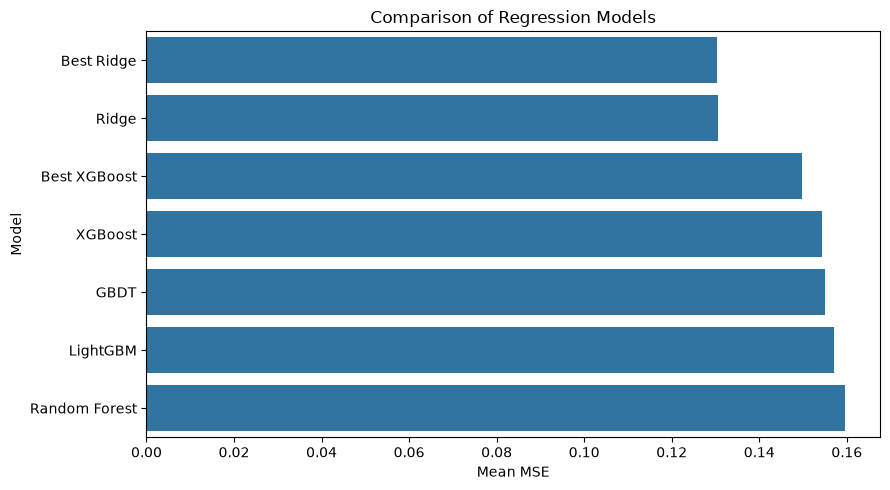

In [58]:
plot_df = final_model_comparison.sort_values(
    "mse_mean",
    ascending=True
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=plot_df,
    x="mse_mean",
    y="model"
)

plt.xlabel("Mean MSE")
plt.ylabel("Model")
plt.title("Comparison of Regression Models")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "model_mse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. 模型融合与可解释性分析

### 5.1 基于交叉验证的折外预测

为了进一步提升模型性能，本章尝试对线性模型和非线性模型进行融合。

由于 Best Ridge 和 Best XGBoost 分别代表当前最优线性模型和最优非线性模型，因此首先使用相同的 TimeSeriesSplit 生成折外预测（Out-of-Fold Prediction, OOF）。

OOF 预测能够保证每个验证样本的预测值来自未使用该样本训练的模型，可用于较为公平地评估模型融合效果。

In [59]:
oof_true = []
oof_ridge = []
oof_xgb = []

for train_idx, val_idx in tscv.split(X):

    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    ridge_fold = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=5.0))
    ])

    xgb_fold = XGBRegressor(
        colsample_bytree=1.0,
        learning_rate=0.05,
        max_depth=2,
        n_estimators=300,
        subsample=0.8,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    )

    ridge_fold.fit(X_train_fold, y_train_fold)
    xgb_fold.fit(X_train_fold, y_train_fold)

    ridge_pred = ridge_fold.predict(X_val_fold)
    xgb_pred = xgb_fold.predict(X_val_fold)

    oof_true.extend(y_val_fold.values)
    oof_ridge.extend(ridge_pred)
    oof_xgb.extend(xgb_pred)

oof_true = np.array(oof_true)
oof_ridge = np.array(oof_ridge)
oof_xgb = np.array(oof_xgb)

print("OOF 样本数：", len(oof_true))

OOF 样本数： 2405


### 5.2 Ridge 与 XGBoost 加权融合

Best Ridge 和 Best XGBoost 分别代表当前最优线性模型和最优非线性模型。两类模型的建模机制不同，因此其预测误差可能具有互补性。

本节在相同 OOF 样本上搜索两种模型的最佳线性加权比例，并以 MSE 作为优化目标。

In [60]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

weight_results = []

for ridge_weight in np.arange(0, 1.01, 0.05):
    xgb_weight = 1 - ridge_weight

    blend_pred = (
        ridge_weight * oof_ridge
        + xgb_weight * oof_xgb
    )

    mse = mean_squared_error(oof_true, blend_pred)

    weight_results.append({
        "ridge_weight": ridge_weight,
        "xgb_weight": xgb_weight,
        "mse": mse
    })

weight_results_df = pd.DataFrame(weight_results)

best_weight_row = weight_results_df.loc[
    weight_results_df["mse"].idxmin()
]

display(weight_results_df)

print("最佳 Ridge 权重：", best_weight_row["ridge_weight"])
print("最佳 XGBoost 权重：", best_weight_row["xgb_weight"])
print("融合模型 MSE：", best_weight_row["mse"])

,ridge_weight,xgb_weight,mse
0,0.00,1.00,0.152253
1,0.05,0.95,0.148675
2,0.10,0.90,0.145359
3,0.15,0.85,0.142305
4,0.20,0.80,0.139512
5,0.25,0.75,0.136980
6,0.30,0.70,0.134709
7,0.35,0.65,0.132700
8,0.40,0.60,0.130953
9,0.45,0.55,0.129466


最佳 Ridge 权重： 0.7000000000000001
最佳 XGBoost 权重： 0.29999999999999993
融合模型 MSE： 0.12595591736078293


### 5.3 最优加权融合模型评估

权重搜索结果表明，当 Ridge 权重为 0.7、XGBoost 权重为 0.3 时，融合模型取得最低 OOF MSE。

因此，本节进一步计算该融合模型的 RMSE、MAE 和 R²，并与单模型结果进行比较。

In [61]:
best_ridge_weight = best_weight_row["ridge_weight"]
best_xgb_weight = best_weight_row["xgb_weight"]

best_blend_pred = (
    best_ridge_weight * oof_ridge
    + best_xgb_weight * oof_xgb
)

blend_mse = mean_squared_error(oof_true, best_blend_pred)
blend_rmse = np.sqrt(blend_mse)
blend_mae = mean_absolute_error(oof_true, best_blend_pred)
blend_r2 = r2_score(oof_true, best_blend_pred)

print("融合 MSE：", blend_mse)
print("融合 RMSE：", blend_rmse)
print("融合 MAE：", blend_mae)
print("融合 R²：", blend_r2)

weight_results_df.to_csv(
    RESULTS_DIR / "weighted_blending_search.csv",
    index=False
)

blend_summary = pd.DataFrame({
    "model": ["Weighted Ridge + XGBoost"],
    "mse": [blend_mse],
    "rmse": [blend_rmse],
    "mae": [blend_mae],
    "r2": [blend_r2],
    "ridge_weight": [best_ridge_weight],
    "xgb_weight": [best_xgb_weight]
})

blend_summary.to_csv(
    RESULTS_DIR / "weighted_blending_summary.csv",
    index=False
)

融合 MSE： 0.12595591736078293
融合 RMSE： 0.35490268717041706
融合 MAE： 0.2592881063417717
融合 R²： 0.8718372880787185


### 5.4 Stacking 融合

与固定权重的加权融合不同，Stacking 不人为指定两个基础模型的权重，而是将基础模型的预测结果作为新的二层特征，再训练一个元学习器自动学习不同模型之间的组合关系。

本实验使用 Best Ridge 和 Best XGBoost 的 OOF 预测作为二层输入，并使用 Ridge 回归作为元学习器。

In [62]:
stack_X = pd.DataFrame({
    "ridge_pred": oof_ridge,
    "xgb_pred": oof_xgb
})

stack_y = oof_true

display(stack_X.head())

print("Stacking 二层特征形状：", stack_X.shape)
print("Stacking 目标形状：", stack_y.shape)

,ridge_pred,xgb_pred
0,0.887577,1.121736
1,-0.043744,0.084541
2,-0.033736,0.089530
3,0.266686,0.499130
4,0.240656,0.473750


Stacking 二层特征形状： (2405, 2)
Stacking 目标形状： (2405,)


In [63]:
split_point = int(len(stack_X) * 0.8)

stack_X_train = stack_X.iloc[:split_point]
stack_X_test = stack_X.iloc[split_point:]

stack_y_train = stack_y[:split_point]
stack_y_test = stack_y[split_point:]

print("二层训练集：", stack_X_train.shape, stack_y_train.shape)
print("二层测试集：", stack_X_test.shape, stack_y_test.shape)

二层训练集： (1924, 2) (1924,)
二层测试集： (481, 2) (481,)


In [64]:
weight_results_holdout = []

ridge_train_pred = stack_X_train["ridge_pred"].values
xgb_train_pred = stack_X_train["xgb_pred"].values

for ridge_weight in np.arange(0, 1.01, 0.05):
    xgb_weight = 1 - ridge_weight

    blend_train_pred = (
        ridge_weight * ridge_train_pred
        + xgb_weight * xgb_train_pred
    )

    mse = mean_squared_error(
        stack_y_train,
        blend_train_pred
    )

    weight_results_holdout.append({
        "ridge_weight": ridge_weight,
        "xgb_weight": xgb_weight,
        "train_mse": mse
    })

weight_holdout_df = pd.DataFrame(weight_results_holdout)

best_holdout_weight = weight_holdout_df.loc[
    weight_holdout_df["train_mse"].idxmin()
]

print("训练集最佳 Ridge 权重：", best_holdout_weight["ridge_weight"])
print("训练集最佳 XGBoost 权重：", best_holdout_weight["xgb_weight"])
print("训练集最优 MSE：", best_holdout_weight["train_mse"])

训练集最佳 Ridge 权重： 0.7000000000000001
训练集最佳 XGBoost 权重： 0.29999999999999993
训练集最优 MSE： 0.11329647519947934


In [65]:
ridge_test_pred = stack_X_test["ridge_pred"].values
xgb_test_pred = stack_X_test["xgb_pred"].values

ridge_weight = best_holdout_weight["ridge_weight"]
xgb_weight = best_holdout_weight["xgb_weight"]

blend_test_pred = (
    ridge_weight * ridge_test_pred
    + xgb_weight * xgb_test_pred
)

blend_test_mse = mean_squared_error(
    stack_y_test,
    blend_test_pred
)

blend_test_rmse = np.sqrt(blend_test_mse)

blend_test_mae = mean_absolute_error(
    stack_y_test,
    blend_test_pred
)

blend_test_r2 = r2_score(
    stack_y_test,
    blend_test_pred
)

print("独立二层测试集 MSE：", blend_test_mse)
print("独立二层测试集 RMSE：", blend_test_rmse)
print("独立二层测试集 MAE：", blend_test_mae)
print("独立二层测试集 R²：", blend_test_r2)

独立二层测试集 MSE： 0.17659368600599726
独立二层测试集 RMSE： 0.42023051531986255
独立二层测试集 MAE： 0.2870096989812513
独立二层测试集 R²： 0.8189850075859839


In [66]:
ridge_holdout_mse = mean_squared_error(
    stack_y_test,
    ridge_test_pred
)

xgb_holdout_mse = mean_squared_error(
    stack_y_test,
    xgb_test_pred
)

ridge_holdout_rmse = np.sqrt(ridge_holdout_mse)
xgb_holdout_rmse = np.sqrt(xgb_holdout_mse)

ridge_holdout_mae = mean_absolute_error(
    stack_y_test,
    ridge_test_pred
)

xgb_holdout_mae = mean_absolute_error(
    stack_y_test,
    xgb_test_pred
)

ridge_holdout_r2 = r2_score(
    stack_y_test,
    ridge_test_pred
)

xgb_holdout_r2 = r2_score(
    stack_y_test,
    xgb_test_pred
)

holdout_comparison = pd.DataFrame({
    "model": [
        "Best Ridge",
        "Best XGBoost",
        "Weighted Blend"
    ],
    "mse": [
        ridge_holdout_mse,
        xgb_holdout_mse,
        blend_test_mse
    ],
    "rmse": [
        ridge_holdout_rmse,
        xgb_holdout_rmse,
        blend_test_rmse
    ],
    "mae": [
        ridge_holdout_mae,
        xgb_holdout_mae,
        blend_test_mae
    ],
    "r2": [
        ridge_holdout_r2,
        xgb_holdout_r2,
        blend_test_r2
    ]
})

display(holdout_comparison)

,model,mse,rmse,mae,r2
0,Best Ridge,0.176921,0.420620,0.288160,0.818649
1,Best XGBoost,0.196809,0.443632,0.303161,0.798263
2,Weighted Blend,0.176594,0.420231,0.287010,0.818985


### 5.5 Stacking 的二层模型训练与测试

In [67]:
from sklearn.linear_model import Ridge

stack_meta_model = Ridge(alpha=1.0)

stack_meta_model.fit(
    stack_X_train,
    stack_y_train
)

stack_test_pred = stack_meta_model.predict(
    stack_X_test
)

stack_test_mse = mean_squared_error(
    stack_y_test,
    stack_test_pred
)

stack_test_rmse = np.sqrt(stack_test_mse)

stack_test_mae = mean_absolute_error(
    stack_y_test,
    stack_test_pred
)

stack_test_r2 = r2_score(
    stack_y_test,
    stack_test_pred
)

print("Stacking MSE：", stack_test_mse)
print("Stacking RMSE：", stack_test_rmse)
print("Stacking MAE：", stack_test_mae)
print("Stacking R²：", stack_test_r2)

print("二层系数：", stack_meta_model.coef_)
print("二层截距：", stack_meta_model.intercept_)

Stacking MSE： 0.17895645446793568
Stacking RMSE： 0.42303245084500984
Stacking MAE： 0.2904751455516313
Stacking R²： 0.8165630834227421
二层系数： [0.67798393 0.29241627]
二层截距： -0.01960894973833796


### 5.6 基于 SHAP 的特征贡献分析

为了进一步解释模型的预测机制，本节使用 SHAP（SHapley Additive exPlanations）分析 Best XGBoost 模型。

SHAP 可以为每个样本、每个特征计算一个贡献值：

- SHAP 值大于 0：该特征推动预测值升高；
- SHAP 值小于 0：该特征推动预测值降低；
- SHAP 绝对值越大：该特征对当前预测的影响越强。

因此，SHAP 不仅能够给出特征重要性，还能够分析特征值变化对预测结果的贡献方向。

In [68]:
import shap

best_xgb_model.fit(X, y)

explainer = shap.TreeExplainer(best_xgb_model)

shap_values = explainer.shap_values(X)

print("SHAP 值形状：", shap_values.shape)

SHAP 值形状： (2888, 38)


### 5.7 SHAP Summary Plot

SHAP Summary Plot 综合展示所有样本中各特征的贡献情况。

纵轴按照平均绝对 SHAP 值对特征进行排序，越靠上的特征整体影响越大；横轴表示 SHAP 值，正值表示推动预测结果升高，负值表示推动预测结果降低。

图中颜色表示原始特征值大小，可以进一步观察高特征值和低特征值对预测方向的影响。

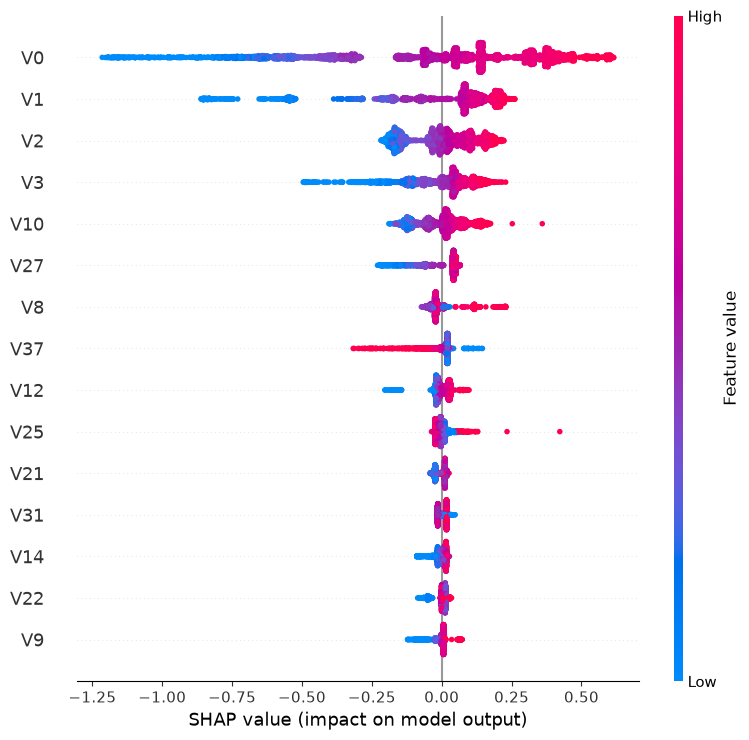

In [69]:
plt.figure()

shap.summary_plot(
    shap_values,
    X,
    show=False,
    max_display=15
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### SHAP 分析结论

SHAP 分析表明，V0 和 V1 是 XGBoost 模型中贡献最显著的两个特征，其特征值升高通常会推动预测结果增大，而较低的特征值则会明显降低预测结果。

V2、V3 和 V10 同样表现出较明显的正向贡献趋势。相比之下，V37 呈现相反的作用方向：较高的 V37 特征值主要对应负 SHAP 值，表明其升高通常会降低模型预测值。

该结果与前述 Pearson 相关性分析总体一致，例如 V0、V1 与目标变量呈较强正相关，而 V37 呈负相关。这说明不同分析方法对主要特征作用方向给出了较一致的结论。

此外，部分特征虽然与目标变量具有一定相关性，但其 SHAP 值主要集中在零附近，说明在考虑其他特征共同作用后，其独立边际贡献相对有限。

### 5.8 基于平均绝对 SHAP 值的特征重要性排名

SHAP Summary Plot 可以同时观察特征重要性和贡献方向，但不同特征的整体重要程度还可以通过平均绝对 SHAP 值进行量化。

对于每个特征，计算其在全部样本上的绝对 SHAP 值平均值。该值越大，说明该特征对模型预测结果的总体影响越强。

In [70]:
shap_importance_df = pd.DataFrame({
    "feature": X.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance_df = (
    shap_importance_df
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance_df.head(15))

shap_importance_df.to_csv(
    RESULTS_DIR / "shap_feature_importance.csv",
    index=False
)

,feature,mean_abs_shap
0,V0,0.328930
1,V1,0.179399
2,V2,0.097770
3,V3,0.090486
4,V10,0.064958
5,V27,0.061549
6,V8,0.036216
7,V37,0.026866
8,V12,0.020765
9,V25,0.015467


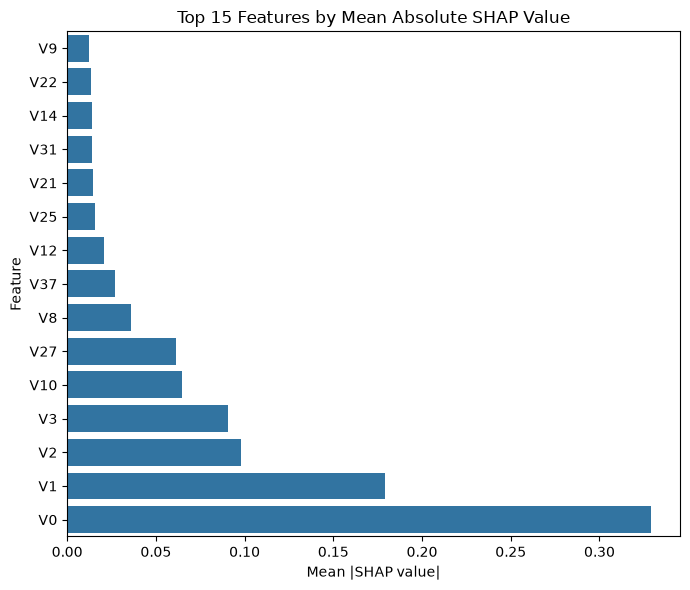

In [71]:
top15_shap = shap_importance_df.head(15).sort_values(
    "mean_abs_shap",
    ascending=True
)

plt.figure(figsize=(7, 6))

sns.barplot(
    data=top15_shap,
    x="mean_abs_shap",
    y="feature"
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("Top 15 Features by Mean Absolute SHAP Value")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.9 SHAP Dependence Plot

平均绝对 SHAP 值能够衡量特征整体重要性，但无法直接展示特征值变化与模型输出之间的关系。

因此，本节使用 SHAP Dependence Plot 分析关键特征。横轴表示原始特征值，纵轴表示对应 SHAP 值，可以观察特征值变化对模型预测结果的影响趋势。

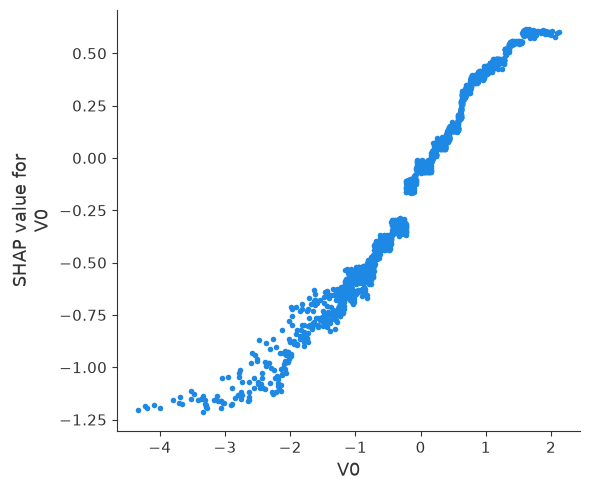

In [72]:
shap.dependence_plot(
    "V0",
    shap_values,
    X,
    interaction_index=None,
    show=False
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "shap_dependence_V0.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

V0 的 SHAP dependence plot 表明，其对模型输出具有明显的单调正向影响。随着 V0 增大，SHAP 值整体由负逐渐转为正，说明较低的 V0 会显著降低预测结果，而较高的 V0 会推动预测结果升高。同时，该关系具有一定非线性特征，在高值区域出现贡献趋于饱和的现象。

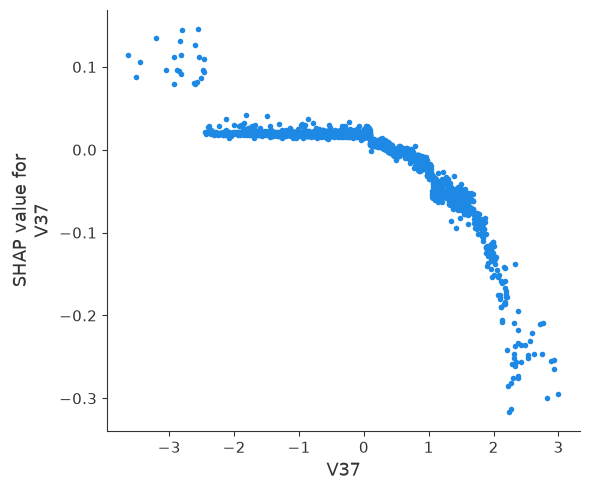

In [73]:
shap.dependence_plot(
    "V37",
    shap_values,
    X,
    interaction_index=None,
    show=False
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "shap_dependence_V37.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

V37 的 SHAP dependence plot 表明，该特征对模型输出整体呈负向影响。随着 V37 增大，其 SHAP 值逐渐下降，尤其在 V37 大于约 1 后，负向贡献明显增强。这说明较高的 V37 会显著降低模型预测结果。该现象与 Pearson 相关性分析以及 SHAP Summary Plot 中观察到的负向作用趋势一致。

## 6. 最终模型结果与误差分析

### 6.1 真实值与预测值对比

为了直观评估最终融合模型的预测效果，本节在独立二层测试集上比较真实值与预测值。

如果模型预测准确，则散点应尽量分布在理想预测线 `y=x` 附近。偏离该直线越远，说明预测误差越大。

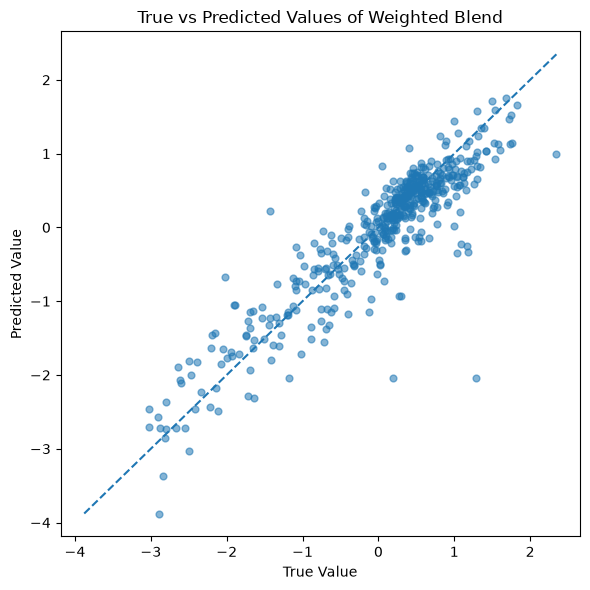

In [74]:
plt.figure(figsize=(6, 6))

plt.scatter(
    stack_y_test,
    blend_test_pred,
    alpha=0.55,
    s=24
)

min_value = min(stack_y_test.min(), blend_test_pred.min())
max_value = max(stack_y_test.max(), blend_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("True Value")
plt.ylabel("Predicted Value")
plt.title("True vs Predicted Values of Weighted Blend")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "weighted_blend_true_vs_pred.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.2 残差分析

残差定义为真实值与预测值之差：

`Residual = True Value - Predicted Value`

理想情况下，残差应随机分布在 0 附近，并且不应随预测值变化呈现明显规律。

如果残差出现趋势、漏斗形分布或较多极端值，则说明模型可能存在系统性偏差或对部分样本预测不稳定。

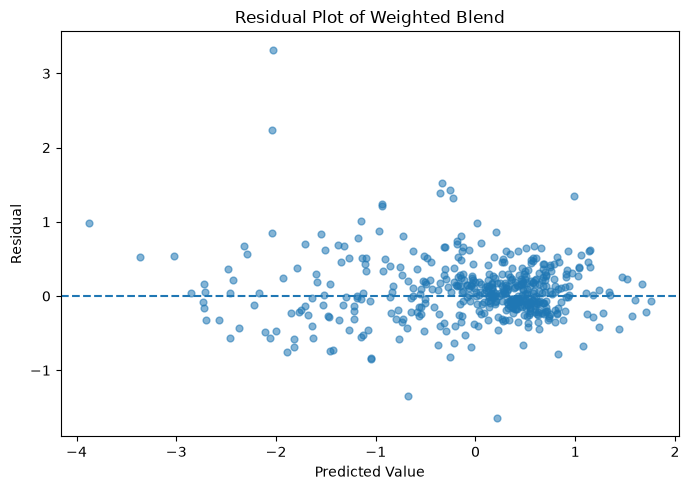

In [75]:
residuals = stack_y_test - blend_test_pred

plt.figure(figsize=(7, 5))

plt.scatter(
    blend_test_pred,
    residuals,
    alpha=0.55,
    s=24
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Value")
plt.ylabel("Residual")
plt.title("Residual Plot of Weighted Blend")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "weighted_blend_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.3 残差分布分析

除了观察残差与预测值之间的关系，还需要分析残差本身的分布情况。

理想情况下，残差应主要集中在 0 附近。如果分布明显偏斜或存在较长尾部，则说明模型在部分样本上的预测误差较大。

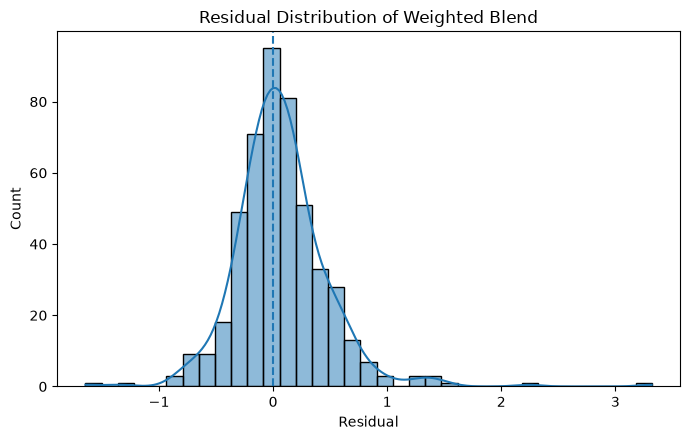

In [76]:
plt.figure(figsize=(7, 4.5))

sns.histplot(
    residuals,
    bins=35,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution of Weighted Blend")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "weighted_blend_residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

残差总体集中在 0 附近，说明融合模型在多数样本上的预测较为稳定。但残差分布存在一定右偏，并伴随少量较大的正残差，表明模型对部分样本存在明显低估现象。后续需要进一步定位这些大误差样本并分析其特征表现。

In [77]:
error_analysis_df = pd.DataFrame({
    "true_value": stack_y_test,
    "predicted_value": blend_test_pred,
    "residual": residuals,
    "absolute_error": np.abs(residuals)
})

error_analysis_df = (
    error_analysis_df
    .sort_values("absolute_error", ascending=False)
    .reset_index(drop=True)
)

display(error_analysis_df.head(10))

error_analysis_df.to_csv(
    RESULTS_DIR / "weighted_blend_error_analysis.csv",
    index=False
)

,true_value,predicted_value,residual,absolute_error
0,1.284,-2.034732,3.318732,3.318732
1,0.194,-2.040442,2.234442,2.234442
2,-1.428,0.216643,-1.644643,1.644643
3,1.186,-0.331791,1.517791,1.517791
4,1.173,-0.252409,1.425409,1.425409
5,1.033,-0.352799,1.385799,1.385799
6,2.346,0.991484,1.354516,1.354516
7,-2.016,-0.675171,-1.340829,1.340829
8,1.094,-0.229980,1.323980,1.323980
9,0.303,-0.933923,1.236923,1.236923


### 6.4 最终模型与误差分析小结

本章对最终加权融合模型进行了预测结果与误差分析。

在独立二层测试集上，加权融合模型的 MSE 为 0.1766，略优于 Best Ridge 的 0.1769，同时其 MAE 和 R² 也取得了轻微改善，说明 Ridge 与 XGBoost 之间存在一定预测互补性。

真实值与预测值散点图显示，大部分样本分布在理想预测线附近，说明模型整体能够较好地拟合目标变量。残差主要集中在 0 附近，没有明显的整体系统性偏差。

然而，残差分布存在一定右长尾，并出现少量绝对误差较大的样本。最大绝对误差达到约 3.32，说明模型对部分特殊样本仍存在明显预测失准。后续可以结合这些样本的原始特征、异常值情况以及 SHAP 解释结果进一步分析其误差来源。

综合模型性能、融合实验和误差分析结果，本文最终采用 Ridge 与 XGBoost 按 0.7:0.3 权重进行加权融合作为主要预测方案，同时保留 Best Ridge 作为性能稳定的单模型基线。

## 7. 最终模型训练与测试集预测

### 7.1 使用全部训练数据重新训练基础模型

前面的交叉验证和独立二层测试主要用于模型选择与性能评估。

确定最终方案后，需要使用全部训练数据重新训练 Best Ridge 和 Best XGBoost，以充分利用已有样本信息，并用于对官方测试集进行预测。

In [78]:
final_ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=5.0))
])

final_xgb_model = XGBRegressor(
    colsample_bytree=1.0,
    learning_rate=0.05,
    max_depth=2,
    n_estimators=300,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)

final_ridge_model.fit(X, y)
final_xgb_model.fit(X, y)

print("最终 Ridge 训练完成")
print("最终 XGBoost 训练完成")

最终 Ridge 训练完成
最终 XGBoost 训练完成


### 7.2 官方测试集预测与最终加权融合

分别使用训练完成的 Best Ridge 和 Best XGBoost 对官方测试集进行预测。

根据前面的融合实验，最终采用 Ridge 与 XGBoost 按 0.7:0.3 的比例进行加权，得到最终测试集预测结果。

In [79]:
ridge_test_final_pred = final_ridge_model.predict(X_test)
xgb_test_final_pred = final_xgb_model.predict(X_test)

final_test_pred = (
    0.7 * ridge_test_final_pred
    + 0.3 * xgb_test_final_pred
)

print("测试集预测数量：", len(final_test_pred))
print("前 10 个预测值：")
print(final_test_pred[:10])

测试集预测数量： 1925
前 10 个预测值：
[ 0.25835127  0.23136698 -0.04285992  0.07833868  0.29615723  0.20871079
 -0.12204399  0.19858827 -0.01546605  0.26480432]


### 7.3 保存最终预测结果

将最终融合模型对官方测试集的预测结果保存到 `results/` 目录，便于后续提交、论文结果整理和复现实验。

同时分别保存 Ridge、XGBoost 和加权融合三种预测结果，便于后续对比分析。

In [80]:
prediction_df = pd.DataFrame({
    "ridge_prediction": ridge_test_final_pred,
    "xgboost_prediction": xgb_test_final_pred,
    "weighted_prediction": final_test_pred
})

display(prediction_df.head(10))

prediction_df.to_csv(
    RESULTS_DIR / "test_predictions_all_models.csv",
    index=False
)

pd.DataFrame({
    "prediction": final_test_pred
}).to_csv(
    RESULTS_DIR / "final_test_prediction.csv",
    index=False
)

print("预测结果已保存")

,ridge_prediction,xgboost_prediction,weighted_prediction
0,0.269400,0.232570,0.258351
1,0.257989,0.169248,0.231367
2,-0.067348,0.014279,-0.042860
3,0.088188,0.055357,0.078339
4,0.274750,0.346108,0.296157
5,0.197425,0.235045,0.208711
6,-0.134404,-0.093205,-0.122044
7,0.229625,0.126168,0.198588
8,-0.064743,0.099514,-0.015466
9,0.285711,0.216023,0.264804


预测结果已保存


### 7.4 保存最终模型

为了保证实验可复现，并方便后续直接加载模型进行预测，本节将训练完成的 Best Ridge 和 Best XGBoost 保存到 `models/` 目录。

由于最终加权融合本身不需要额外训练，因此只需保存两个基础模型及其固定融合权重。

In [81]:
import joblib

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(
    final_ridge_model,
    MODELS_DIR / "best_ridge_model.joblib"
)

joblib.dump(
    final_xgb_model,
    MODELS_DIR / "best_xgboost_model.joblib"
)

fusion_config = {
    "ridge_weight": 0.7,
    "xgboost_weight": 0.3
}

joblib.dump(
    fusion_config,
    MODELS_DIR / "weighted_fusion_config.joblib"
)

print("模型与融合配置已保存")

模型与融合配置已保存


### 7.5 最终实验总结

本项目围绕工业蒸汽量预测任务，完成了从数据质量检查、探索性分析、特征处理、模型比较、参数优化、模型融合、SHAP 可解释性分析到最终测试集预测的完整机器学习流程。

实验结果表明：

1. Ridge 在基础模型中表现最佳，说明当前数据中存在较明显的线性关系；
2. KBest 和 PCA 均未能提升 Ridge 性能，其中 PCA 造成了较明显的性能下降；
3. XGBoost 是表现最好的树模型，经过参数优化后性能进一步提升；
4. Ridge 与 XGBoost 存在一定互补性，0.7:0.3 的加权融合在独立二层测试集上取得了略优于 Best Ridge 的结果；
5. Stacking 未超过简单加权融合，说明更复杂的融合方式并不一定带来更好的泛化性能；
6. SHAP 分析表明 V0、V1、V2、V3 等特征对模型预测贡献较大，其中 V0 和 V1 主要表现为正向作用，而 V37 具有较明显的负向贡献；
7. 最终使用全部训练数据重新训练 Best Ridge 和 Best XGBoost，并按照 0.7:0.3 的权重生成官方测试集预测结果，同时保存模型与融合配置以保证实验可复现。

总体而言，本项目建立了一套较完整、可复现、可解释的工业回归预测流程，为后续论文撰写、科研作图和模型进一步优化提供了实验基础。

## 8. 验证策略稳健性分析

前述实验主要采用 5 折 `TimeSeriesSplit`，该策略保持样本原始顺序，不进行随机打乱。

但目前并没有充分证据证明数据行顺序具有严格的时间语义，因此为了检验模型结论是否过度依赖某一种数据划分方式，本节增加普通 5 折 `KFold` 作为对照。

本节保持模型完全不变，仍使用当前表现最好的单模型：

- StandardScaler
- Ridge
- alpha = 5

仅改变交叉验证策略：

1. `TimeSeriesSplit(n_splits=5)`；
2. `KFold(n_splits=5, shuffle=True, random_state=42)`。

通过比较 MSE、RMSE、MAE 和 R²，判断模型性能及“Ridge 为强基线模型”这一结论是否对验证策略具有一定稳健性。

需要注意，本节并不用于证明哪一种划分方式绝对正确，而是作为一种验证策略敏感性分析。

### 8.1 构建 KFold 对照策略

In [82]:
# =========================
# 8.1 构建 KFold 对照策略
# =========================

from sklearn.model_selection import KFold

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("TimeSeriesSplit：", tscv)
print("KFold：", kfold)
print("对照模型：")
print(best_ridge_pipeline)

TimeSeriesSplit： TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)
KFold： KFold(n_splits=5, random_state=42, shuffle=True)
对照模型：
Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge(alpha=5.0))])


### 8.2 TimeSeriesSplit 与 KFold 性能对比

为了公平比较两种验证策略，本节保持 Best Ridge 模型及其参数完全一致，仅改变交叉验证方式。

评价指标包括：

- MSE：均方误差，越小越好；
- RMSE：均方根误差，越小越好；
- MAE：平均绝对误差，越小越好；
- R²：决定系数，越大越好。

如果两种验证策略下的性能差异不大，则说明模型结论对数据划分方式具有一定稳健性；如果差异明显，则说明实验结果对验证策略较为敏感，论文中需要谨慎解释。

In [83]:
# =========================
# 8.2 验证策略性能对比
# =========================

from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np

scoring = {
    "mse": "neg_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

# TimeSeriesSplit
tscv_scores = cross_validate(
    best_ridge_pipeline,
    X,
    y,
    cv=tscv,
    scoring=scoring,
    n_jobs=-1
)

# KFold
kfold_scores = cross_validate(
    best_ridge_pipeline,
    X,
    y,
    cv=kfold,
    scoring=scoring,
    n_jobs=-1
)

def summarize_cv(scores):
    mse_values = -scores["test_mse"]
    mae_values = -scores["test_mae"]
    r2_values = scores["test_r2"]

    rmse_values = np.sqrt(mse_values)

    return {
        "MSE": mse_values.mean(),
        "RMSE": rmse_values.mean(),
        "MAE": mae_values.mean(),
        "R2": r2_values.mean()
    }

validation_strategy_comparison = pd.DataFrame({
    "TimeSeriesSplit": summarize_cv(tscv_scores),
    "KFold": summarize_cv(kfold_scores)
}).T

display(validation_strategy_comparison)

,MSE,RMSE,MAE,R2
TimeSeriesSplit,0.130369,0.359262,0.263933,0.852496
KFold,0.112940,0.335365,0.244574,0.882662


### 8.3 验证策略稳健性分析结论

在保持 Best Ridge 模型及其参数完全一致的情况下，KFold 验证得到的 MSE、RMSE 和 MAE 均低于 TimeSeriesSplit，同时 R² 更高。

该结果表明，模型性能对数据划分策略存在一定敏感性。KFold 随机打乱样本后获得了更优的平均预测性能，而保持原始样本顺序的 TimeSeriesSplit 给出了更保守的评估结果。

需要强调的是，该对比本身不能证明 KFold 或 TimeSeriesSplit 哪一种策略绝对正确。验证策略的最终选择取决于数据样本顺序是否具有明确的时间语义。


### 8.4 数据顺序与验证策略说明

根据公开数据说明，该工业蒸汽量预测数据来源于锅炉传感器的分钟级采集数据，因此原始数据生成过程具有明显的时间属性。

但是，目前公开说明中并没有明确给出 `zhengqi_train.txt` 文件中的样本行是否严格按照时间顺序排列，也没有提供可直接用于验证时间先后关系的时间戳字段。

因此，本文不直接将“文件行号”视为严格时间轴，而采用以下处理方式：

1. 主实验保留 `TimeSeriesSplit`，其目的在于保持样本原始顺序，获得相对保守的性能估计；
2. 额外采用随机 5 折 `KFold` 进行敏感性分析；
3. 两种划分方式下均保持模型结构、超参数和评价指标不变，仅改变验证策略。

实验结果表明，KFold 下 Best Ridge 的预测性能优于 TimeSeriesSplit：

| Validation Strategy | MSE | RMSE | MAE | R² |
|---|---:|---:|---:|---:|
| TimeSeriesSplit | 0.130369 | 0.361067 | 0.263933 | 0.852496 |
| KFold | 0.112940 | 0.336066 | 0.244574 | 0.882662 |

该结果说明模型性能估计对数据划分策略存在一定敏感性。随机 KFold 获得了更优的平均性能，而保持原始顺序的 TimeSeriesSplit 给出了更保守的估计。

因此，在后续论文中不将 KFold 的更优结果直接解释为模型性能提升，而将两种验证结果共同用于说明验证策略对性能估计的影响。

### 8.5 保存验证策略对比结果

In [84]:
# =========================
# 8.5 保存验证策略对比结果
# =========================

validation_strategy_comparison.to_csv(
    RESULTS_DIR / "validation_strategy_comparison.csv",
    index=True
)

print("已保存：results/validation_strategy_comparison.csv")

已保存：results/validation_strategy_comparison.csv


## 9 论文前结果整理

### 9.1 Fig. 2 模型性能绘图数据整理

In [88]:
ridge_baseline_cv_metrics = pd.read_csv(
    RESULTS_DIR / "ridge_baseline_cv_metrics.csv"
)

best_ridge_cv_metrics = pd.read_csv(
    RESULTS_DIR / "best_ridge_cv_metrics.csv"
)

xgboost_cv_metrics = pd.read_csv(
    RESULTS_DIR / "xgboost_cv_metrics.csv"
)

best_xgboost_cv_metrics = pd.read_csv(
    RESULTS_DIR / "best_xgboost_cv_metrics.csv"
)

gbdt_cv_metrics = pd.read_csv(
    RESULTS_DIR / "gbdt_cv_metrics.csv"
)

lightgbm_cv_metrics = pd.read_csv(
    RESULTS_DIR / "lightgbm_cv_metrics.csv"
)

random_forest_cv_metrics = pd.read_csv(
    RESULTS_DIR / "random_forest_cv_metrics.csv"
)

print("Fig. 2 CV files loaded successfully.")

Fig. 2 CV files loaded successfully.


In [89]:
paper_fig2_df = pd.DataFrame({
    "model": [
        "Ridge",
        "Best Ridge",
        "XGBoost",
        "Best XGBoost",
        "GBDT",
        "LightGBM",
        "Random Forest"
    ],
    "mse_mean": [
        ridge_baseline_cv_metrics["mse"].mean(),
        best_ridge_cv_metrics["mse"].mean(),
        xgboost_cv_metrics["mse"].mean(),
        best_xgboost_cv_metrics["mse"].mean(),
        gbdt_cv_metrics["mse"].mean(),
        lightgbm_cv_metrics["mse"].mean(),
        random_forest_cv_metrics["mse"].mean()
    ],
    "mse_std": [
        ridge_baseline_cv_metrics["mse"].std(ddof=1),
        best_ridge_cv_metrics["mse"].std(ddof=1),
        xgboost_cv_metrics["mse"].std(ddof=1),
        best_xgboost_cv_metrics["mse"].std(ddof=1),
        gbdt_cv_metrics["mse"].std(ddof=1),
        lightgbm_cv_metrics["mse"].std(ddof=1),
        random_forest_cv_metrics["mse"].std(ddof=1)
    ],
    "rmse_mean": [
        ridge_baseline_cv_metrics["rmse"].mean(),
        best_ridge_cv_metrics["rmse"].mean(),
        xgboost_cv_metrics["rmse"].mean(),
        best_xgboost_cv_metrics["rmse"].mean(),
        gbdt_cv_metrics["rmse"].mean(),
        lightgbm_cv_metrics["rmse"].mean(),
        random_forest_cv_metrics["rmse"].mean()
    ],
    "mae_mean": [
        ridge_baseline_cv_metrics["mae"].mean(),
        best_ridge_cv_metrics["mae"].mean(),
        xgboost_cv_metrics["mae"].mean(),
        best_xgboost_cv_metrics["mae"].mean(),
        gbdt_cv_metrics["mae"].mean(),
        lightgbm_cv_metrics["mae"].mean(),
        random_forest_cv_metrics["mae"].mean()
    ],
    "r2_mean": [
        ridge_baseline_cv_metrics["r2"].mean(),
        best_ridge_cv_metrics["r2"].mean(),
        xgboost_cv_metrics["r2"].mean(),
        best_xgboost_cv_metrics["r2"].mean(),
        gbdt_cv_metrics["r2"].mean(),
        lightgbm_cv_metrics["r2"].mean(),
        random_forest_cv_metrics["r2"].mean()
    ]
})

paper_fig2_df = paper_fig2_df.sort_values(
    by="mse_mean",
    ascending=True
).reset_index(drop=True)

display(paper_fig2_df)

paper_fig2_df.to_csv(
    RESULTS_DIR / "paper_fig2_model_performance.csv",
    index=False
)

,model,mse_mean,mse_std,rmse_mean,mae_mean,r2_mean
0,Best Ridge,0.130369,0.030038,0.359262,0.263933,0.852496
1,Ridge,0.130572,0.030034,0.359539,0.264313,0.852306
2,Best XGBoost,0.149834,0.027438,0.385839,0.288822,0.826074
3,XGBoost,0.154234,0.026863,0.391518,0.295241,0.820282
4,GBDT,0.154969,0.024308,0.392722,0.296401,0.820749
5,LightGBM,0.157048,0.028448,0.394963,0.298978,0.818561
6,Random Forest,0.159601,0.029823,0.398076,0.299707,0.816392


### 9.2 Fig. 4 融合模型绘图数据整理

In [90]:
fusion_df = pd.read_csv(
    RESULTS_DIR / "fusion_model_comparison.csv"
)

display(fusion_df)

,model,mse,rmse,mae,r2
0,Weighted Blend,0.176594,0.420231,0.287010,0.818985
1,Best Ridge,0.176921,0.420620,0.288160,0.818649
2,Stacking,0.178956,0.423032,0.290475,0.816563
3,Best XGBoost,0.196809,0.443632,0.303161,0.798263


In [91]:
best_ridge_mse = fusion_df.loc[
    fusion_df["model"] == "Best Ridge",
    "mse"
].iloc[0]

paper_fig4_df = fusion_df.copy()

paper_fig4_df["mse_difference_vs_best_ridge"] = (
    paper_fig4_df["mse"] - best_ridge_mse
)

paper_fig4_df["mse_change_percent_vs_best_ridge"] = (
    (paper_fig4_df["mse"] - best_ridge_mse)
    / best_ridge_mse
    * 100
)

paper_fig4_df = paper_fig4_df.sort_values(
    by="mse",
    ascending=True
).reset_index(drop=True)

display(paper_fig4_df)

paper_fig4_df.to_csv(
    RESULTS_DIR / "paper_fig4_fusion_comparison.csv",
    index=False
)

,model,mse,rmse,mae,r2,mse_difference_vs_best_ridge,mse_change_percent_vs_best_ridge
0,Weighted Blend,0.176594,0.420231,0.287010,0.818985,-0.000328,-0.185205
1,Best Ridge,0.176921,0.420620,0.288160,0.818649,0.000000,0.000000
2,Stacking,0.178956,0.423032,0.290475,0.816563,0.002035,1.150286
3,Best XGBoost,0.196809,0.443632,0.303161,0.798263,0.019888,11.241071


### 9.3 Fig. 6 加权融合预测与残差诊断数据整理

In [92]:
paper_fig6_df = pd.read_csv(
    RESULTS_DIR / "weighted_blend_error_analysis.csv"
)

display(paper_fig6_df.head())
print("shape:", paper_fig6_df.shape)
print("missing values:")
print(paper_fig6_df.isna().sum())

,true_value,predicted_value,residual,absolute_error
0,1.284,-2.034732,3.318732,3.318732
1,0.194,-2.040442,2.234442,2.234442
2,-1.428,0.216643,-1.644643,1.644643
3,1.186,-0.331791,1.517791,1.517791
4,1.173,-0.252409,1.425409,1.425409


shape: (481, 4)
missing values:
true_value         0
predicted_value    0
residual           0
absolute_error     0
dtype: int64


In [93]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

fig6_mse = mean_squared_error(
    paper_fig6_df["true_value"],
    paper_fig6_df["predicted_value"]
)

fig6_rmse = np.sqrt(fig6_mse)

fig6_mae = mean_absolute_error(
    paper_fig6_df["true_value"],
    paper_fig6_df["predicted_value"]
)

fig6_r2 = r2_score(
    paper_fig6_df["true_value"],
    paper_fig6_df["predicted_value"]
)

print("N   :", len(paper_fig6_df))
print("MSE :", fig6_mse)
print("RMSE:", fig6_rmse)
print("MAE :", fig6_mae)
print("R2  :", fig6_r2)

N   : 481
MSE : 0.1765936860059972
RMSE: 0.4202305153198625
MAE : 0.28700969898125117
R2  : 0.8189850075859839


In [94]:
paper_fig6_export = paper_fig6_df[
    [
        "true_value",
        "predicted_value",
        "residual",
        "absolute_error"
    ]
].copy()

paper_fig6_export.to_csv(
    RESULTS_DIR / "paper_fig6_prediction_diagnostics.csv",
    index=False
)

print(paper_fig6_export.shape)
display(paper_fig6_export.head())

(481, 4)


,true_value,predicted_value,residual,absolute_error
0,1.284,-2.034732,3.318732,3.318732
1,0.194,-2.040442,2.234442,2.234442
2,-1.428,0.216643,-1.644643,1.644643
3,1.186,-0.331791,1.517791,1.517791
4,1.173,-0.252409,1.425409,1.425409
